# ABCD initial test

ABCD isolation plane을 background group별로 같은 순서로 비교한다. 기본 group 순서는 `TTJets`, `QCD`, `DY`, `BKG total`이다. 없는 `.coffea` 파일은 load 단계에서 skip되므로 DY output이 추가되면 kernel restart 후 다시 실행하면 자동으로 포함된다.


In [ ]:
# python
import sys
import os
import importlib
from pathlib import Path

import coffea.util
import hist
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import mplhep as hep
import numpy as np
import pandas as pd

# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities

importlib.reload(utilities)
utilities.set_plot_style()
%matplotlib inline


## Inputs and Groups


In [ ]:
OUTPUT_DIR = Path("base")
CHANNEL = "base"

qcd_samples = [
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt800To1000",
    "QCD_Pt1000",
]

dy_samples = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
]

diboson_samples = [
    "WW",
    "WZ",
    "ZZ",
]

sample_outputs = {"TTJets": OUTPUT_DIR / "TTJets.coffea"}
sample_outputs.update({sample: OUTPUT_DIR / f"{sample}.coffea" for sample in qcd_samples})
sample_outputs.update({sample: OUTPUT_DIR / f"{sample}.coffea" for sample in dy_samples})
sample_outputs.update({sample: OUTPUT_DIR / f"{sample}.coffea" for sample in diboson_samples})

group_definitions = {
    "TTJets": ["TTJets"],
    "QCD": qcd_samples,
    "DY": dy_samples,
    "Diboson": diboson_samples,
}
GROUP_ORDER = ["TTJets", "QCD", "DY", "Diboson", "BKG total"]

hist_configs = {
    "mulj_egmlj_iso": {
        "cuts": (0.25, 0.10),
        "x_label": "mu-LJ isolation cut",
        "y_label": "egamma-LJ isolation cut",
    },
    "mulj_mulj_iso": {
        "cuts": (0.25, 0.25),
        "x_label": "leading mu-LJ isolation cut",
        "y_label": "subleading mu-LJ isolation cut",
    },
}

scan_values_default = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])
scan_values_egm = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])

sample_outputs


In [20]:
# Load available outputs. Missing samples are skipped so this notebook can be rerun as new outputs appear.
outputs = {}
missing_samples = []
for sample, path in sample_outputs.items():
    if not path.exists():
        missing_samples.append(sample)
        continue
    loaded = coffea.util.load(path)
    outputs[sample] = loaded["out"][sample]

sample_groups = {}
for group, samples in group_definitions.items():
    available_samples = [sample for sample in samples if sample in outputs]
    if available_samples:
        sample_groups[group] = available_samples

all_background_samples = []
for group in ["TTJets", "QCD", "DY", "Diboson"]:
    all_background_samples.extend(sample_groups.get(group, []))
if all_background_samples:
    sample_groups["BKG total"] = all_background_samples

print("Loaded samples:")
for sample in outputs:
    print(f"  {sample}")

if missing_samples:
    print()
    print("Missing samples skipped:")
    for sample in missing_samples:
        print(f"  {sample}: {sample_outputs[sample]}")

print()
print("Available groups:")
for group in GROUP_ORDER:
    if group in sample_groups:
        print(f"  {group}: {sample_groups[group]}")


Loaded samples:
  TTJets
  QCD_Pt15To20
  QCD_Pt20To30
  QCD_Pt30To50
  QCD_Pt50To80
  QCD_Pt80To120
  QCD_Pt120To170
  QCD_Pt170To300
  QCD_Pt300To470
  QCD_Pt470To600
  QCD_Pt600To800
  QCD_Pt800To1000
  QCD_Pt1000
  DYJetsToMuMu_M10to50
  DYJetsToMuMu_M50
  WW
  WZ
  ZZ

Available groups:
  TTJets: ['TTJets']
  QCD: ['QCD_Pt15To20', 'QCD_Pt20To30', 'QCD_Pt30To50', 'QCD_Pt50To80', 'QCD_Pt80To120', 'QCD_Pt120To170', 'QCD_Pt170To300', 'QCD_Pt300To470', 'QCD_Pt470To600', 'QCD_Pt600To800', 'QCD_Pt800To1000', 'QCD_Pt1000']
  DY: ['DYJetsToMuMu_M10to50', 'DYJetsToMuMu_M50']
  Diboson: ['WW', 'WZ', 'ZZ']
  BKG total: ['TTJets', 'QCD_Pt15To20', 'QCD_Pt20To30', 'QCD_Pt30To50', 'QCD_Pt50To80', 'QCD_Pt80To120', 'QCD_Pt120To170', 'QCD_Pt170To300', 'QCD_Pt300To470', 'QCD_Pt470To600', 'QCD_Pt600To800', 'QCD_Pt800To1000', 'QCD_Pt1000', 'DYJetsToMuMu_M10to50', 'DYJetsToMuMu_M50', 'WW', 'WZ', 'ZZ']


In [21]:
# Quick histogram content check.
for group in GROUP_ORDER:
    if group not in sample_groups:
        continue
    print(group)
    for hist_name in hist_configs:
        total = 0.0
        for sample in sample_groups[group]:
            total += float(outputs[sample]["hists"][hist_name].values().sum())
        print(f"  {hist_name}: total={total:.3f}")


TTJets
  mulj_egmlj_iso: total=4596.322
  mulj_mulj_iso: total=394.617
QCD
  mulj_egmlj_iso: total=76033.149
  mulj_mulj_iso: total=28263.107
DY
  mulj_egmlj_iso: total=1240.315
  mulj_mulj_iso: total=140.315
Diboson
  mulj_egmlj_iso: total=57.888
  mulj_mulj_iso: total=11.902
BKG total
  mulj_egmlj_iso: total=81927.675
  mulj_mulj_iso: total=28809.942


## ABCD Helpers


In [22]:
def get_channel_hist(out_sample, hist_name, channel=CHANNEL):
    """Return a 2D hist after selecting the channel axis."""
    return out_sample["hists"][hist_name][channel, :, :]


def combined_hist(outputs, samples, hist_name, channel=CHANNEL):
    """Return a summed 2D hist for a list of samples."""
    h_sum = None
    for sample in samples:
        h = get_channel_hist(outputs[sample], hist_name, channel=channel).copy()
        h_sum = h if h_sum is None else h_sum + h
    return h_sum


def group_hist(group, hist_name, channel=CHANNEL):
    return combined_hist(outputs, sample_groups[group], hist_name, channel=channel)


def iter_available_groups():
    for group in GROUP_ORDER:
        if group in sample_groups:
            yield group


In [23]:
def abcd_regions(h2d, x_cut, y_cut):
    """Integrate a 2D isolation histogram into low-low(A), high-low(B), low-high(C), high-high(D)."""
    x_centers = h2d.axes[0].centers
    y_centers = h2d.axes[1].centers
    values = h2d.values()
    variances = h2d.variances()
    if variances is None:
        variances = values

    masks = {
        "A": (x_centers < x_cut, y_centers < y_cut),
        "B": (x_centers >= x_cut, y_centers < y_cut),
        "C": (x_centers < x_cut, y_centers >= y_cut),
        "D": (x_centers >= x_cut, y_centers >= y_cut),
    }

    regions = {}
    for name, (x_mask, y_mask) in masks.items():
        mask = x_mask[:, None] & y_mask[None, :]
        value = float(values[mask].sum())
        variance = float(variances[mask].sum())
        regions[name] = {
            "yield": value,
            "variance": variance,
            "error": np.sqrt(variance) if variance >= 0 else np.nan,
        }

    return regions


def abcd_prediction(regions):
    """Compute A prediction from B*C/D with simple variance propagation."""
    B = regions["B"]["yield"]
    C = regions["C"]["yield"]
    D = regions["D"]["yield"]
    var_B = regions["B"]["variance"]
    var_C = regions["C"]["variance"]
    var_D = regions["D"]["variance"]

    if B <= 0 or C <= 0 or D <= 0:
        return {"pred": np.nan, "pred_error": np.nan, "closure": np.nan, "closure_error": np.nan}

    pred = B * C / D
    rel_var_pred = var_B / B**2 + var_C / C**2 + var_D / D**2
    pred_error = abs(pred) * np.sqrt(rel_var_pred)

    A = regions["A"]["yield"]
    var_A = regions["A"]["variance"]
    closure = A / pred if pred > 0 else np.nan
    closure_error = abs(closure) * np.sqrt(var_A / A**2 + rel_var_pred) if A > 0 and pred > 0 else np.nan

    return {
        "pred": pred,
        "pred_error": pred_error,
        "closure": closure,
        "closure_error": closure_error,
    }


def abcd_result_from_h2d(h2d, x_cut, y_cut):
    regions = abcd_regions(h2d, x_cut, y_cut)
    prediction = abcd_prediction(regions)
    return regions, prediction


In [24]:
def make_region_table(regions, prediction):
    rows = []
    for region in ["A", "B", "C", "D"]:
        entry = regions[region]
        rows.append({
            "region": region,
            "yield": entry["yield"],
            "error": entry["error"],
        })
    rows.append({
        "region": "A_pred = B*C/D",
        "yield": prediction["pred"],
        "error": prediction["pred_error"],
    })
    rows.append({
        "region": "A/A_pred",
        "yield": prediction["closure"],
        "error": prediction["closure_error"],
    })
    return pd.DataFrame(rows)


def print_region_table(rows):
    if isinstance(rows, pd.DataFrame):
        rows = rows.to_dict("records")
    print("region          value        error")
    for row in rows:
        print(f"{row['region']:<14s} {row['yield']:10.3f} {row['error']:10.3f}")


def print_abcd_result(label, hist_name, x_cut, y_cut, regions, prediction):
    print(f"{label} / {hist_name} / x<{x_cut:.3f}, y<{y_cut:.3f}")
    for region in ["A", "B", "C", "D"]:
        entry = regions[region]
        print(f"  {region}: {entry['yield']:10.3f} +/- {entry['error']:8.3f}")
    print(f"  A_pred = {prediction['pred']:10.3f} +/- {prediction['pred_error']:8.3f}")
    print(f"  A/A_pred = {prediction['closure']:8.3f} +/- {prediction['closure_error']:8.3f}")


## Plot Helpers


In [25]:
def plot_abcd_2d_from_h2d(h2d, x_cut, y_cut, label, hist_name, log_scale=True):
    regions, prediction = abcd_result_from_h2d(h2d, x_cut, y_cut)

    x_edges = h2d.axes[0].edges
    y_edges = h2d.axes[1].edges
    values = h2d.values().T

    fig, ax = plt.subplots(figsize=(16, 12))
    positive_values = values[values > 0]
    if log_scale and positive_values.size > 0:
        norm = LogNorm(vmin=max(float(positive_values.min()), 1e-12), vmax=float(positive_values.max()))
    else:
        norm = None

    mesh = ax.pcolormesh(x_edges, y_edges, values, shading="auto", norm=norm)
    fig.colorbar(mesh, ax=ax, label="Yield")
    ax.axvline(x_cut, color="red", linestyle="--", linewidth=2)
    ax.axhline(y_cut, color="red", linestyle="--", linewidth=2)

    x_min, x_max = x_edges[0], x_edges[-1]
    y_min, y_max = y_edges[0], y_edges[-1]

    label_positions = {
      "A": ((x_min + x_cut) / 2, (y_min + y_cut) / 2),
      "B": ((x_cut + x_max) / 2, (y_min + y_cut) / 2),
      "C": ((x_min + x_cut) / 2, (y_cut + y_max) / 2),
      "D": ((x_cut + x_max) / 2, (y_cut + y_max) / 2),
    }


    for region, (x_pos, y_pos) in label_positions.items():
        is_a = region == "A"

        ax.text(
          x_pos,
          y_pos,
          region,
          ha="center",
          va="center",
          fontsize=28,
          fontweight="bold",
          color="white" if is_a else "black",
          bbox={
              "boxstyle": "round,pad=0.25",
              "facecolor": "red" if is_a else "white",
              "alpha": 0.75 if is_a else 0.55,
              "edgecolor": "none",
          },
      )
          
    ax.set_xlabel(h2d.axes[0].label or h2d.axes[0].name)
    ax.set_ylabel(h2d.axes[1].label or h2d.axes[1].name)
    title = f"{label}: {hist_name}" + chr(10)
    title += f"x < {x_cut:.2f}, y < {y_cut:.2f}; "
    title += f"A/A_pred = {prediction['closure']:.3f} +/- {prediction['closure_error']:.3f}"
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

    return regions, prediction

In [26]:
def scan_one_axis_h2d(h2d, scan_values, fixed_cut, scan_axis="x"):
    rows = []
    for value in scan_values:
        if scan_axis == "x":
            x_cut, y_cut = value, fixed_cut
        elif scan_axis == "y":
            x_cut, y_cut = fixed_cut, value
        else:
            raise ValueError("scan_axis must be 'x' or 'y'")

        regions, prediction = abcd_result_from_h2d(h2d, x_cut, y_cut)
        rows.append({
            "scan_cut": value,
            "x_cut": x_cut,
            "y_cut": y_cut,
            "A": regions["A"]["yield"],
            "A_err": regions["A"]["error"],
            "B": regions["B"]["yield"],
            "C": regions["C"]["yield"],
            "D": regions["D"]["yield"],
            "A_pred": prediction["pred"],
            "A_pred_err": prediction["pred_error"],
            "closure": prediction["closure"],
            "closure_err": prediction["closure_error"],
        })
    return rows


def scan_symmetric_h2d(h2d, scan_values):
    rows = []
    for cut in scan_values:
        regions, prediction = abcd_result_from_h2d(h2d, cut, cut)
        rows.append({
            "scan_cut": cut,
            "x_cut": cut,
            "y_cut": cut,
            "A": regions["A"]["yield"],
            "A_err": regions["A"]["error"],
            "B": regions["B"]["yield"],
            "C": regions["C"]["yield"],
            "D": regions["D"]["yield"],
            "A_pred": prediction["pred"],
            "A_pred_err": prediction["pred_error"],
            "closure": prediction["closure"],
            "closure_err": prediction["closure_error"],
        })
    return rows


def plot_scan(rows, xlabel, title):
    x = np.array([row["scan_cut"] for row in rows])
    closure = np.array([row["closure"] for row in rows])
    closure_err = np.array([row["closure_err"] for row in rows])
    A = np.array([row["A"] for row in rows])
    A_err = np.array([row["A_err"] for row in rows])
    pred = np.array([row["A_pred"] for row in rows])
    pred_err = np.array([row["A_pred_err"] for row in rows])

    fig, axes = plt.subplots(1, 2, figsize=(36, 12))

    axes[0].errorbar(x, closure, yerr=closure_err, marker="o", linestyle="-")
    axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("A / A_pred")
    axes[0].set_title("Closure")

    axes[1].errorbar(x, A, yerr=A_err, marker="o", linestyle="-", label="A observed")
    axes[1].errorbar(x, pred, yerr=pred_err, marker="s", linestyle="--", label="A predicted")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("Yield")
    axes[1].set_title("Yield")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def print_scan(rows):
    print("cut      A          A_pred     A/A_pred")
    for row in rows:
        print(f"{row['scan_cut']:<8.3f} {row['A']:10.3f} {row['A_pred']:10.3f} {row['closure']:10.3f}")


In [27]:
def hist2d_to_dataframe(h2d):
    """Convert a 2D hist to a pandas DataFrame using bin centers and weighted yields."""
    x_centers = np.asarray(h2d.axes[0].centers)
    y_centers = np.asarray(h2d.axes[1].centers)
    values = np.asarray(h2d.values())
    xx, yy = np.meshgrid(x_centers, y_centers, indexing="ij")
    return pd.DataFrame({
        "x": xx.ravel(),
        "y": yy.ravel(),
        "yield": values.ravel(),
    })


def weighted_corr_from_hist2d(h2d):
    """Weighted Pearson correlation of the two histogram axes using bin yields as weights."""
    df = hist2d_to_dataframe(h2d)
    df = df[df["yield"] > 0].copy()
    if df.empty or df["yield"].sum() <= 0:
        return np.nan

    weights = df["yield"].to_numpy()
    x = df["x"].to_numpy()
    y = df["y"].to_numpy()
    x_mean = np.average(x, weights=weights)
    y_mean = np.average(y, weights=weights)
    cov_xy = np.average((x - x_mean) * (y - y_mean), weights=weights)
    var_x = np.average((x - x_mean) ** 2, weights=weights)
    var_y = np.average((y - y_mean) ** 2, weights=weights)
    if var_x <= 0 or var_y <= 0:
        return np.nan
    return cov_xy / np.sqrt(var_x * var_y)


def correlation_summary(groups, hist_names):
    rows = []
    for group in groups:
        for hist_name in hist_names:
            h2d = group_hist(group, hist_name)
            rows.append({
                "group": group,
                "hist": hist_name,
                "total_yield": float(h2d.values().sum()),
                "weighted_corr": weighted_corr_from_hist2d(h2d),
            })
    return pd.DataFrame(rows)


In [28]:
def plot_correlation_view(h2d, label, hist_name, log_scale=True):
    """Show the 2D plane plus x/y profile means as a compact correlation diagnostic."""
    df = hist2d_to_dataframe(h2d)
    corr = weighted_corr_from_hist2d(h2d)

    x_edges = h2d.axes[0].edges
    y_edges = h2d.axes[1].edges
    values = h2d.values().T
    positive_values = values[values > 0]
    if log_scale and positive_values.size > 0:
        norm = LogNorm(vmin=max(float(positive_values.min()), 1e-12), vmax=float(positive_values.max()))
    else:
        norm = None

    fig, axes = plt.subplots(1, 3, figsize=(24, 10))

    mesh = axes[0].pcolormesh(x_edges, y_edges, values, shading="auto", norm=norm)
    fig.colorbar(mesh, ax=axes[0], label="Yield")
    axes[0].set_xlabel(h2d.axes[0].label or h2d.axes[0].name)
    axes[0].set_ylabel(h2d.axes[1].label or h2d.axes[1].name)
    axes[0].set_title(f"2D yield; corr = {corr:.3f}")

    positive_df = df[df["yield"] > 0]
    x_profile = (
        positive_df
        .groupby("x")
        .apply(lambda g: np.average(g["y"], weights=g["yield"]))
        .reset_index(name="weighted_mean_y")
    )
    y_profile = (
        positive_df
        .groupby("y")
        .apply(lambda g: np.average(g["x"], weights=g["yield"]))
        .reset_index(name="weighted_mean_x")
    )

    axes[1].plot(x_profile["x"], x_profile["weighted_mean_y"], marker="o", linestyle="-")
    axes[1].set_xlabel(h2d.axes[0].label or h2d.axes[0].name)
    axes[1].set_ylabel(f"weighted mean {h2d.axes[1].name}")
    axes[1].set_title("Profile: <y> vs x")

    axes[2].plot(y_profile["y"], y_profile["weighted_mean_x"], marker="o", linestyle="-")
    axes[2].set_xlabel(h2d.axes[1].label or h2d.axes[1].name)
    axes[2].set_ylabel(f"weighted mean {h2d.axes[0].name}")
    axes[2].set_title("Profile: <x> vs y")

    fig.suptitle(f"{label}: {hist_name}")
    fig.tight_layout()
    plt.show()

    return corr


def plot_correlation_matrix(h2d, label, hist_name):
    corr = weighted_corr_from_hist2d(h2d)
    names = [h2d.axes[0].name, h2d.axes[1].name]
    matrix = np.array([
        [1.0, corr],
        [corr, 1.0],
    ])

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_yticklabels(names)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax, label="Weighted Pearson correlation")
    ax.set_title(f"{label}: {hist_name}")
    fig.tight_layout()
    plt.show()


## Fixed Working Point ABCD Planes

각 histogram에 대해 `TTJets`, `QCD`, `DY`, `BKG total` 순서로 같은 plot을 반복한다.



===== mulj_egmlj_iso: fixed WP x<0.25, y<0.1 =====


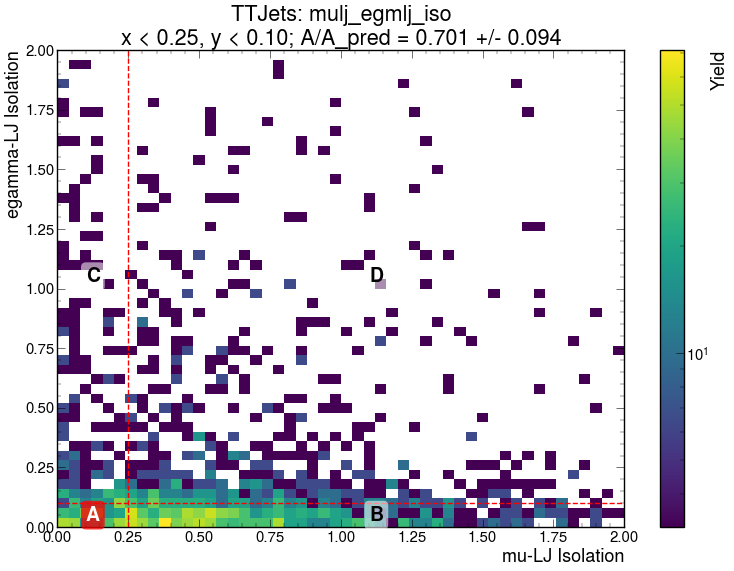

TTJets / mulj_egmlj_iso / x<0.250, y<0.100
  A:    359.037 +/-   34.078
  B:   1659.334 +/-   73.261
  C:    608.099 +/-   44.350
  D:   1969.852 +/-   79.822
  A_pred =    512.241 +/-   48.353
  A/A_pred =    0.701 +/-    0.094
region          value        error
A                 359.037     34.078
B                1659.334     73.261
C                 608.099     44.350
D                1969.852     79.822
A_pred = B*C/D    512.241     48.353
A/A_pred            0.701      0.094



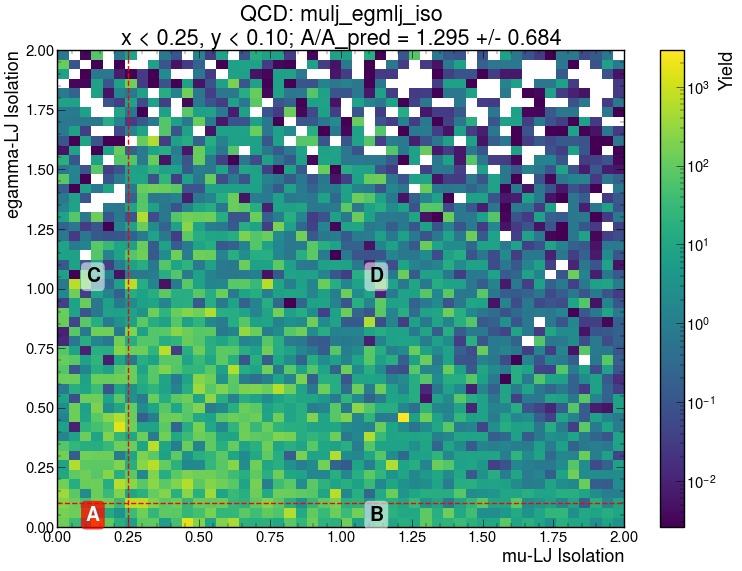

QCD / mulj_egmlj_iso / x<0.250, y<0.100
  A:   1865.680 +/-  803.694
  B:   5929.544 +/- 1525.716
  C:  13340.496 +/- 1951.754
  D:  54897.429 +/- 4067.362
  A_pred =   1440.925 +/-  439.662
  A/A_pred =    1.295 +/-    0.684
region          value        error
A                1865.680    803.694
B                5929.544   1525.716
C               13340.496   1951.754
D               54897.429   4067.362
A_pred = B*C/D   1440.925    439.662
A/A_pred            1.295      0.684



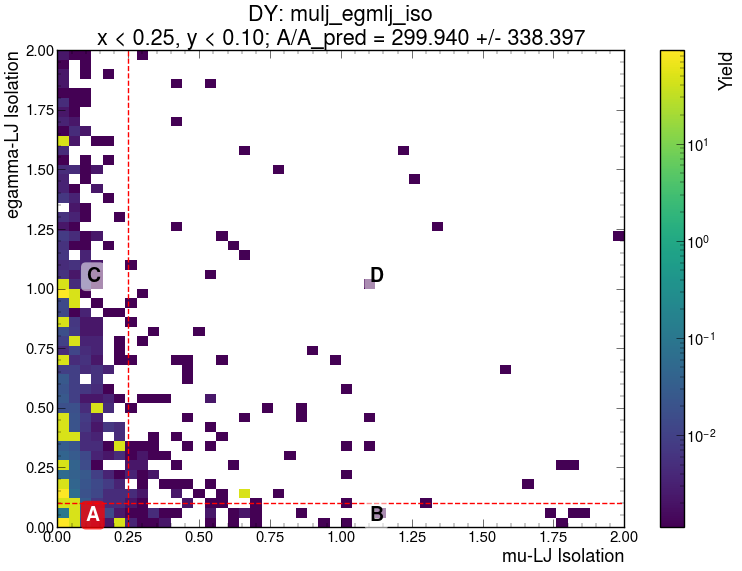

DY / mulj_egmlj_iso / x<0.250, y<0.100
  A:    229.664 +/-  102.534
  B:      0.036 +/-    0.006
  C:    964.641 +/-  210.132
  D:     45.973 +/-   45.855
  A_pred =      0.766 +/-    0.793
  A/A_pred =  299.940 +/-  338.397
region          value        error
A                 229.664    102.534
B                   0.036      0.006
C                 964.641    210.132
D                  45.973     45.855
A_pred = B*C/D      0.766      0.793
A/A_pred          299.940    338.397



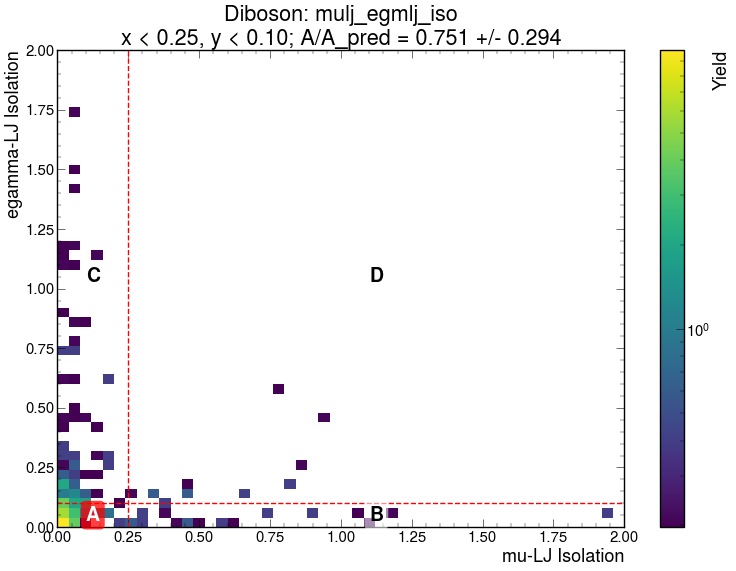

Diboson / mulj_egmlj_iso / x<0.250, y<0.100
  A:     25.816 +/-    2.454
  B:      5.035 +/-    1.192
  C:     23.584 +/-    2.307
  D:      3.452 +/-    0.972
  A_pred =     34.397 +/-   13.091
  A/A_pred =    0.751 +/-    0.294
region          value        error
A                  25.816      2.454
B                   5.035      1.192
C                  23.584      2.307
D                   3.452      0.972
A_pred = B*C/D     34.397     13.091
A/A_pred            0.751      0.294



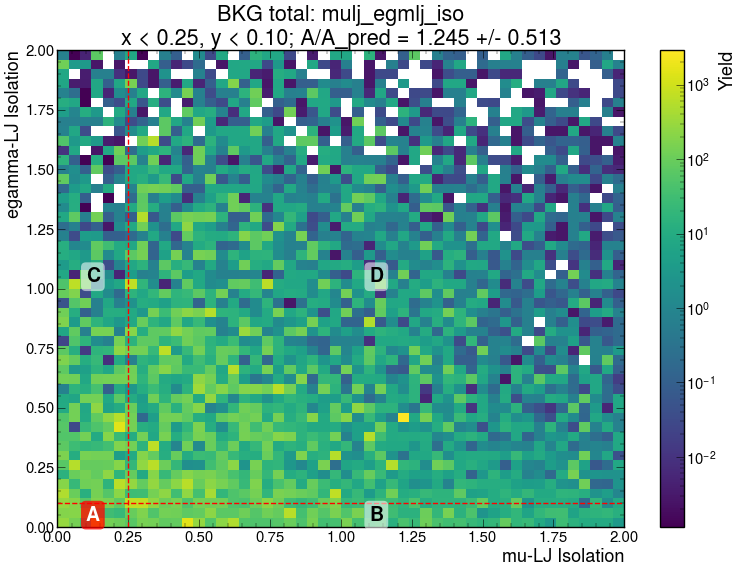

BKG total / mulj_egmlj_iso / x<0.250, y<0.100
  A:   2480.198 +/-  810.929
  B:   7593.950 +/- 1527.474
  C:  14936.820 +/- 1963.535
  D:  56916.707 +/- 4068.404
  A_pred =   1992.903 +/-  499.614
  A/A_pred =    1.245 +/-    0.513
region          value        error
A                2480.198    810.929
B                7593.950   1527.474
C               14936.820   1963.535
D               56916.707   4068.404
A_pred = B*C/D   1992.903    499.614
A/A_pred            1.245      0.513


===== mulj_mulj_iso: fixed WP x<0.25, y<0.25 =====


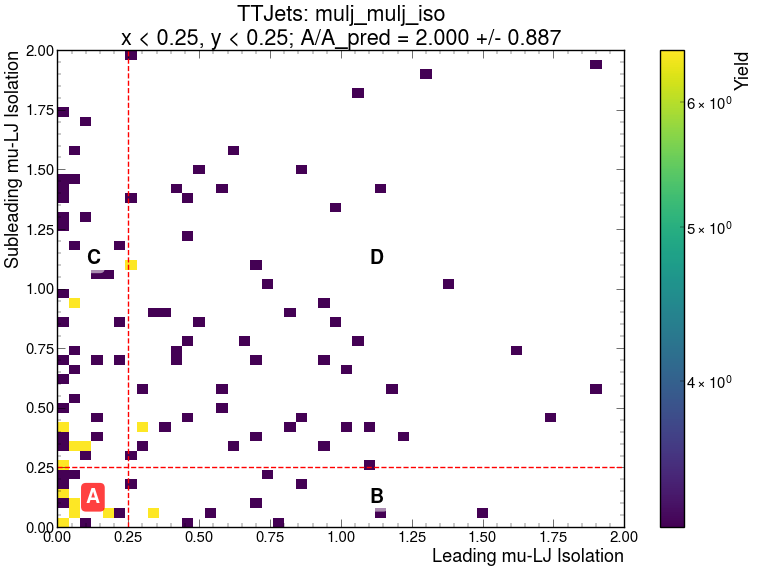

TTJets / mulj_mulj_iso / x<0.250, y<0.250
  A:     51.753 +/-   12.938
  B:     35.580 +/-   10.728
  C:    129.383 +/-   20.457
  D:    177.901 +/-   23.988
  A_pred =     25.877 +/-    9.476
  A/A_pred =    2.000 +/-    0.887
region          value        error
A                  51.753     12.938
B                  35.580     10.728
C                 129.383     20.457
D                 177.901     23.988
A_pred = B*C/D     25.877      9.476
A/A_pred            2.000      0.887



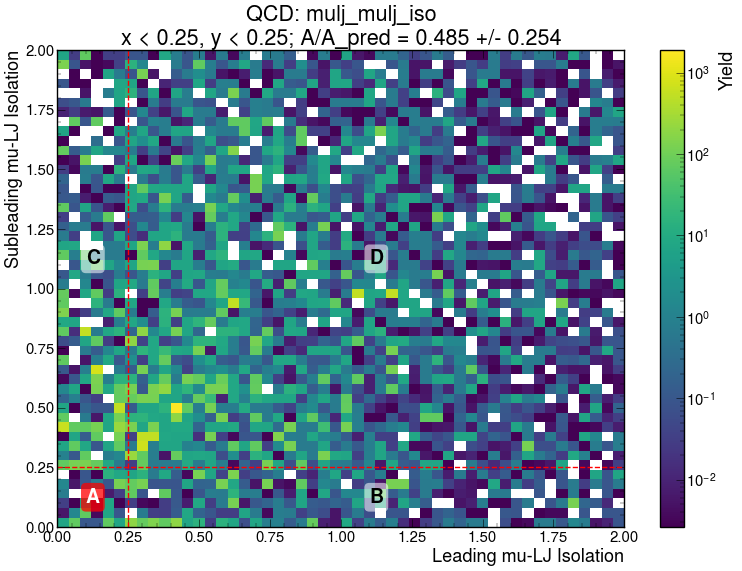

QCD / mulj_mulj_iso / x<0.250, y<0.250
  A:    394.140 +/-  170.621
  B:   2459.437 +/-  460.711
  C:   6313.605 +/- 1228.158
  D:  19095.926 +/- 2205.058
  A_pred =    813.153 +/-  238.830
  A/A_pred =    0.485 +/-    0.254
region          value        error
A                 394.140    170.621
B                2459.437    460.711
C                6313.605   1228.158
D               19095.926   2205.058
A_pred = B*C/D    813.153    238.830
A/A_pred            0.485      0.254



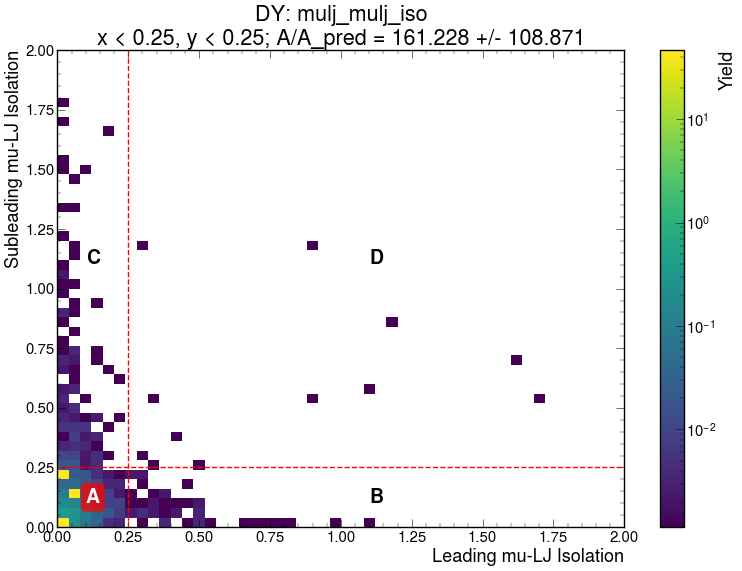

DY / mulj_mulj_iso / x<0.250, y<0.250
  A:    140.052 +/-   79.423
  B:      0.056 +/-    0.008
  C:      0.195 +/-    0.016
  D:      0.013 +/-    0.004
  A_pred =      0.869 +/-    0.318
  A/A_pred =  161.228 +/-  108.871
region          value        error
A                 140.052     79.423
B                   0.056      0.008
C                   0.195      0.016
D                   0.013      0.004
A_pred = B*C/D      0.869      0.318
A/A_pred          161.228    108.871



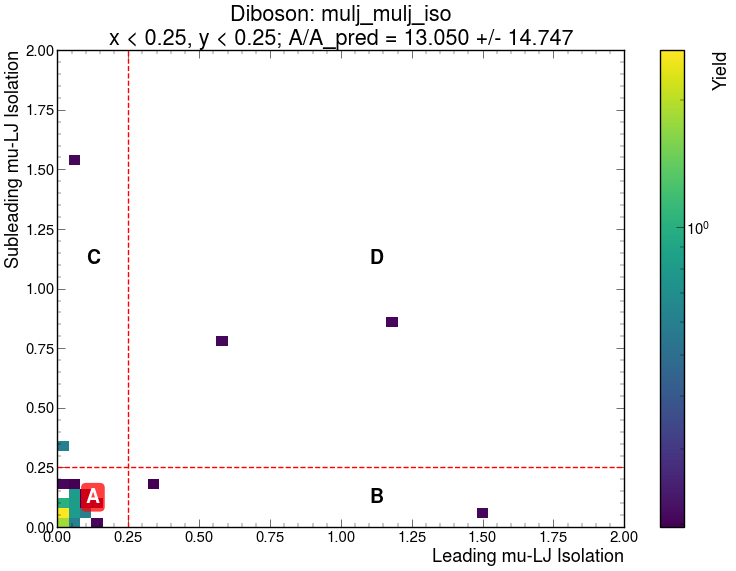

Diboson / mulj_mulj_iso / x<0.250, y<0.250
  A:     10.278 +/-    1.674
  B:      0.403 +/-    0.285
  C:      0.807 +/-    0.404
  D:      0.413 +/-    0.292
  A_pred =      0.788 +/-    0.881
  A/A_pred =   13.050 +/-   14.747
region          value        error
A                  10.278      1.674
B                   0.403      0.285
C                   0.807      0.404
D                   0.413      0.292
A_pred = B*C/D      0.788      0.881
A/A_pred           13.050     14.747



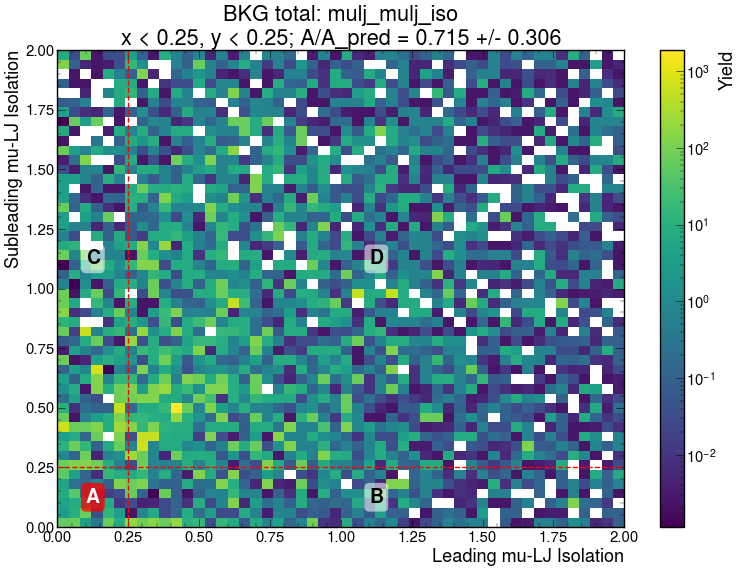

BKG total / mulj_mulj_iso / x<0.250, y<0.250
  A:    596.223 +/-  188.652
  B:   2495.476 +/-  460.836
  C:   6443.990 +/- 1228.329
  D:  19274.253 +/- 2205.189
  A_pred =    834.316 +/-  241.126
  A/A_pred =    0.715 +/-    0.306
region          value        error
A                 596.223    188.652
B                2495.476    460.836
C                6443.990   1228.329
D               19274.253   2205.189
A_pred = B*C/D    834.316    241.126
A/A_pred            0.715      0.306



,group,hist,region,yield,error
0,TTJets,mulj_egmlj_iso,A,359.037094,34.078293
1,TTJets,mulj_egmlj_iso,B,1659.333599,73.261368
2,TTJets,mulj_egmlj_iso,C,608.098863,44.350168
3,TTJets,mulj_egmlj_iso,D,1969.852167,79.822438
4,TTJets,mulj_egmlj_iso,A_pred = B*C/D,512.240914,48.353217
5,TTJets,mulj_egmlj_iso,A/A_pred,0.700915,0.093827
6,QCD,mulj_egmlj_iso,A,1865.680228,803.694369
7,QCD,mulj_egmlj_iso,B,5929.544484,1525.715724
8,QCD,mulj_egmlj_iso,C,13340.495692,1951.753956
9,QCD,mulj_egmlj_iso,D,54897.429003,4067.362038


In [29]:
fixed_wp_tables = []
for hist_name, cfg in hist_configs.items():
    x_cut, y_cut = cfg["cuts"]
    print()
    print(f"===== {hist_name}: fixed WP x<{x_cut}, y<{y_cut} =====")
    for group in iter_available_groups():
        h2d = group_hist(group, hist_name)
        regions, prediction = plot_abcd_2d_from_h2d(
            h2d,
            x_cut,
            y_cut,
            label=group,
            hist_name=hist_name,
            log_scale=True,
        )
        print_abcd_result(group, hist_name, x_cut, y_cut, regions, prediction)
        table = make_region_table(regions, prediction)
        table.insert(0, "group", group)
        table.insert(1, "hist", hist_name)
        fixed_wp_tables.append(table)
        print_region_table(table[["region", "yield", "error"]])
        print()

fixed_wp_df = pd.concat(fixed_wp_tables, ignore_index=True) if fixed_wp_tables else pd.DataFrame()
fixed_wp_df


## Closure Scans

한 종류의 scan을 `TTJets`, `QCD`, `DY`, `BKG total` 순서로 반복한다.



===== mulj_egmlj_iso: scan mu-LJ isolation with egamma-LJ isolation fixed =====

--- TTJets ---
cut      A          A_pred     A/A_pred
0.100       142.321    212.235      0.671
0.150       249.062    341.678      0.729
0.200       294.346    422.925      0.696
0.250       359.037    512.241      0.701
0.300       472.247    574.807      0.822
0.400       711.605    845.078      0.842
0.500       876.568   1004.463      0.873


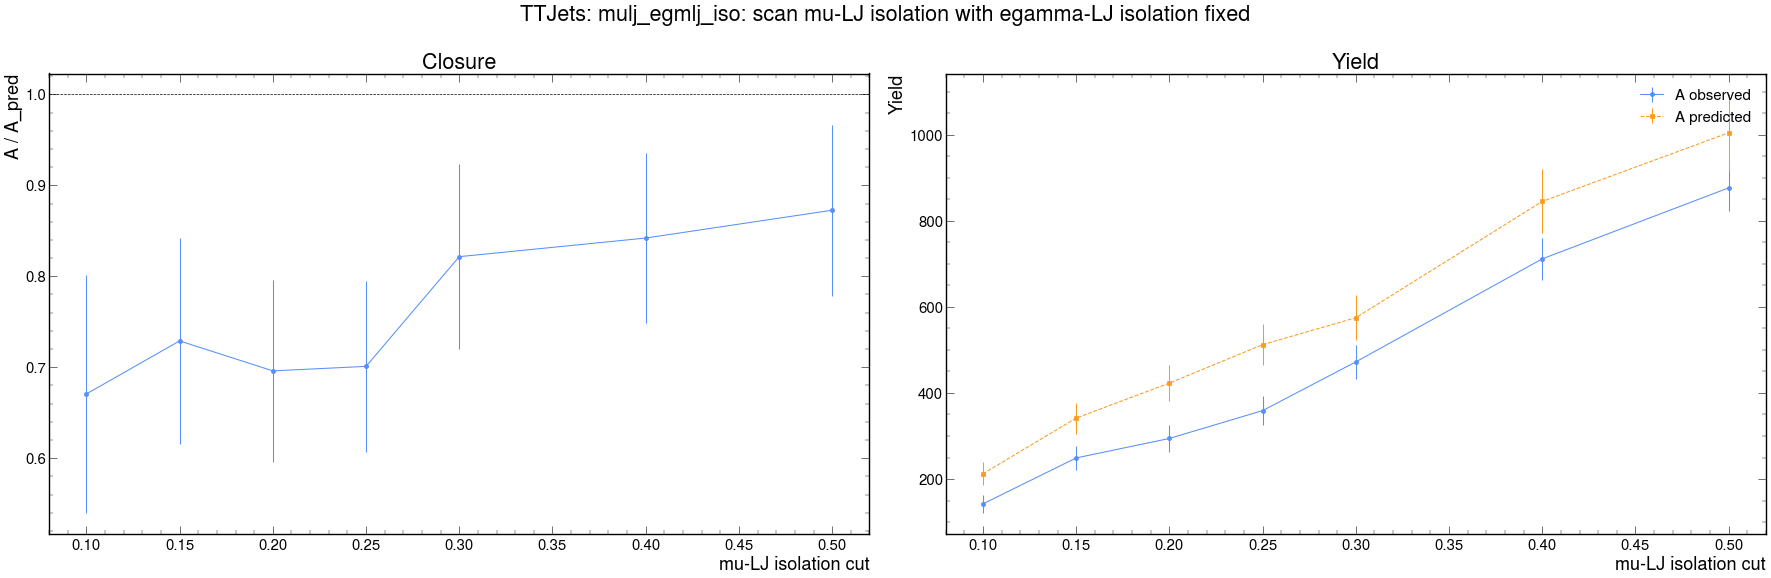


--- QCD ---
cut      A          A_pred     A/A_pred
0.100       452.221    491.257      0.921
0.150      1737.080    752.482      2.308
0.200      1845.423    914.319      2.018
0.250      1865.680   1440.925      1.295
0.300      1905.397   1885.716      1.010
0.400      2355.417   3324.652      0.708
0.500      3946.820   3124.846      1.263


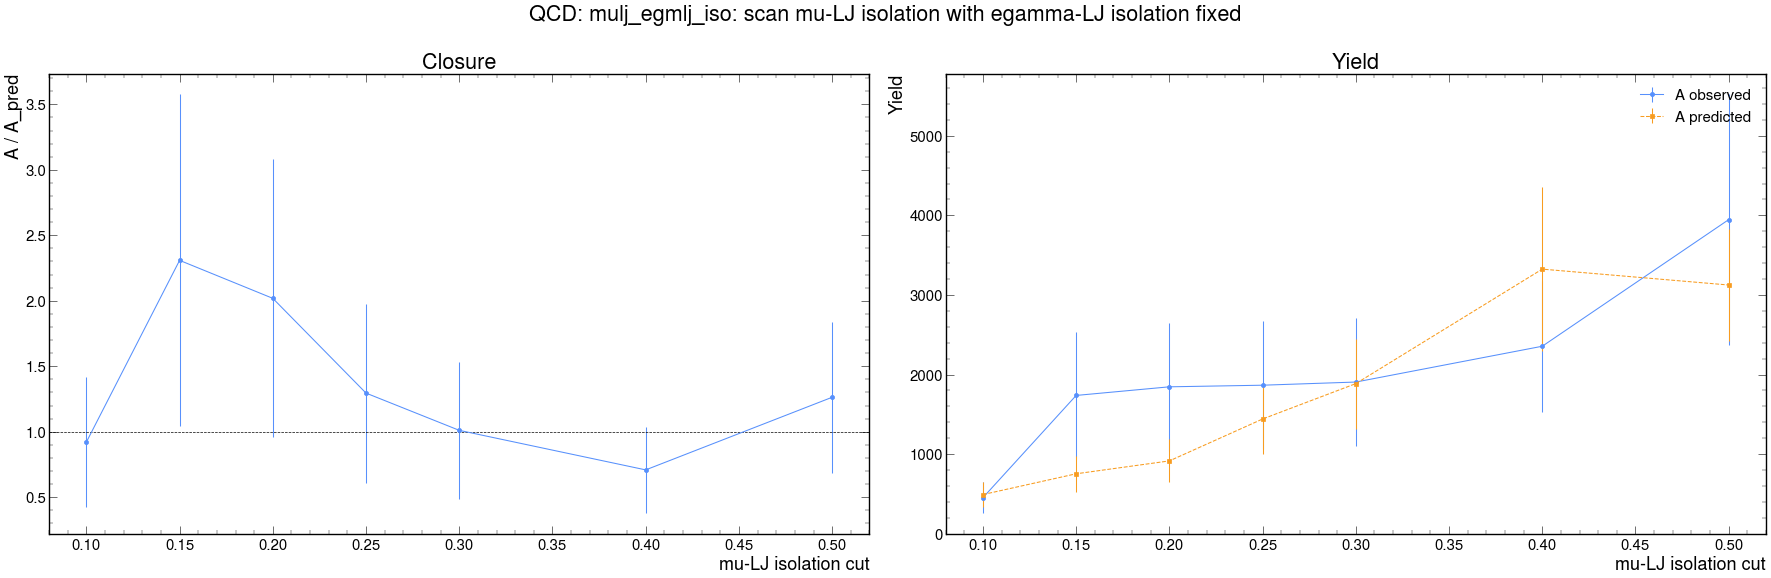


--- DY ---
cut      A          A_pred     A/A_pred
0.100       183.730    290.439      0.633
0.150       183.790    458.889      0.401
0.200       183.806    459.005      0.400
0.250       229.664      0.766    299.940
0.300       229.669      0.670    342.635
0.400       229.680      0.431    532.682
0.500       229.681      0.407    563.769


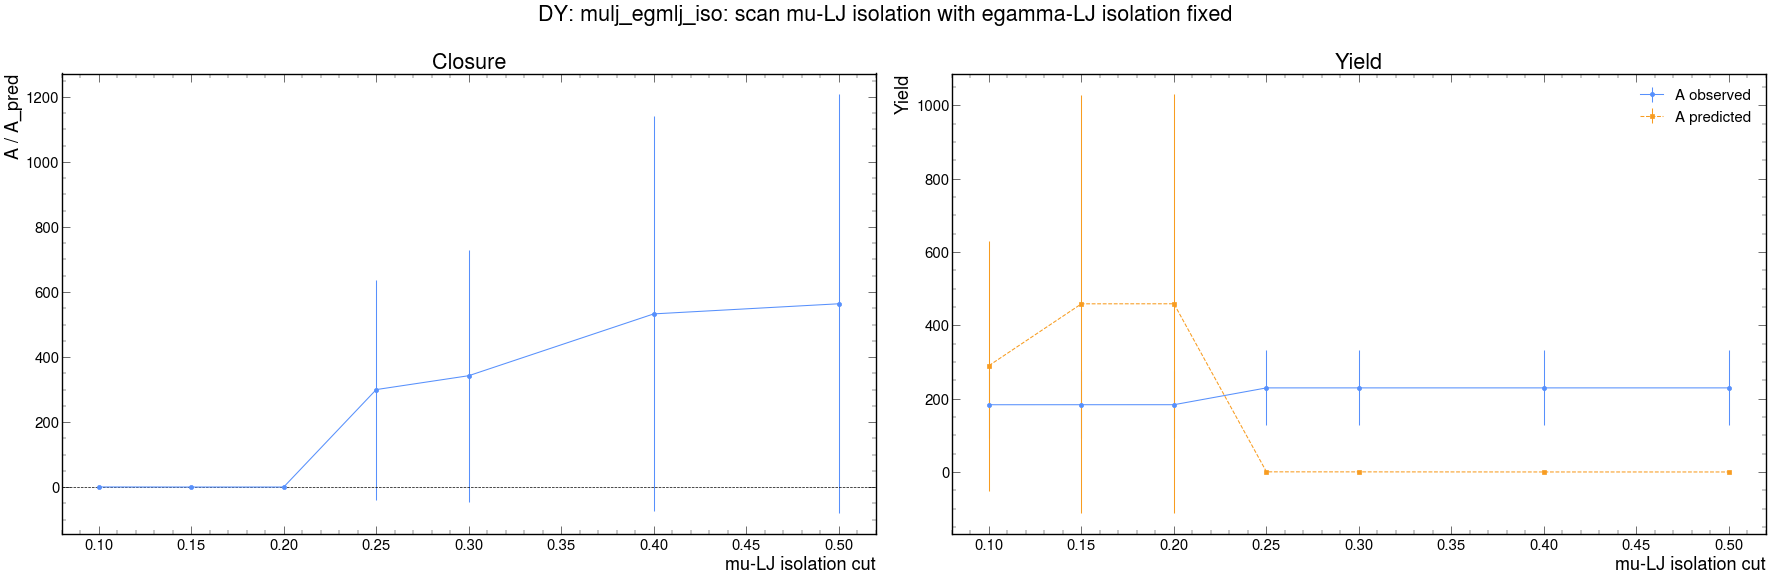


--- Diboson ---
cut      A          A_pred     A/A_pred
0.100        22.551     16.883      1.336
0.150        24.608     28.507      0.863
0.200        25.413     34.852      0.729
0.250        25.816     34.397      0.751
0.300        26.416     32.513      0.812
0.400        27.430     38.201      0.718
0.500        28.236     46.962      0.601


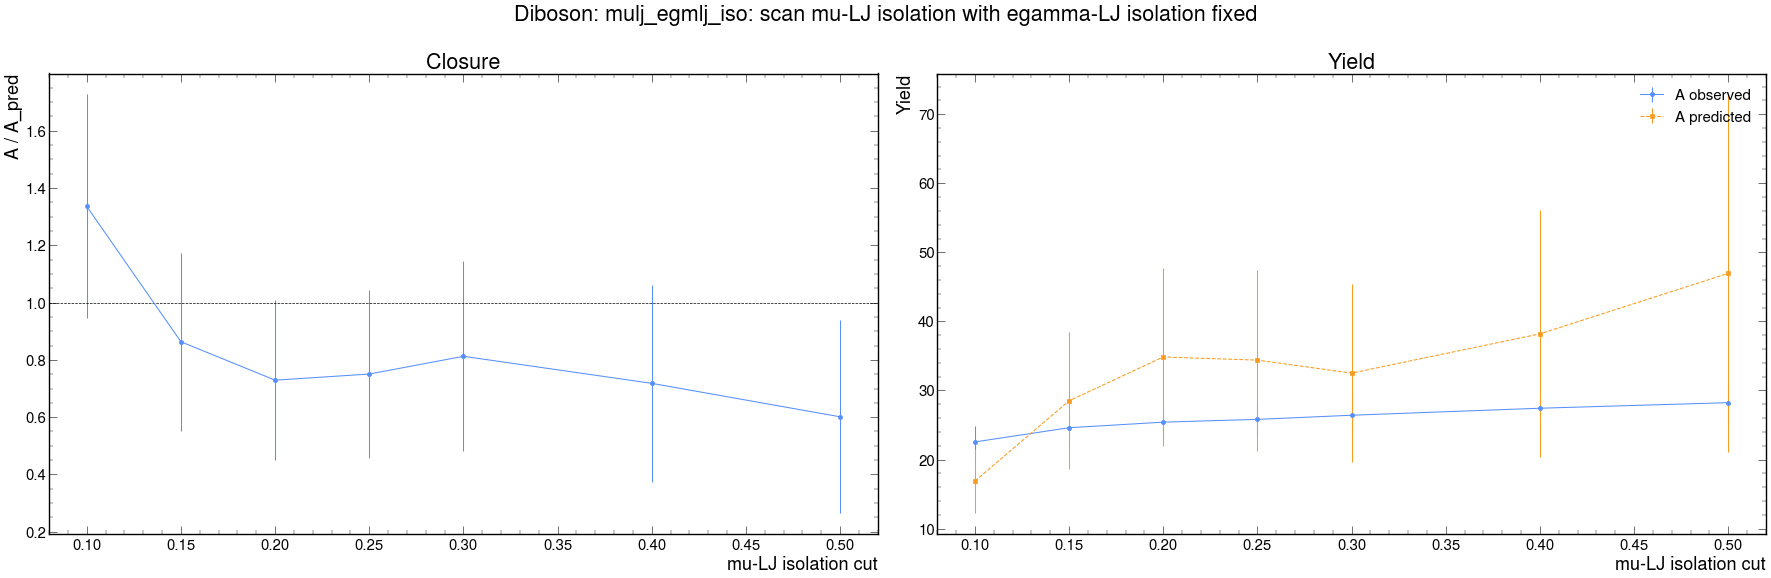


--- BKG total ---
cut      A          A_pred     A/A_pred
0.100       800.823    758.315      1.056
0.150      2194.540   1113.617      1.971
0.200      2348.989   1327.898      1.769
0.250      2480.198   1992.903      1.245
0.300      2633.729   2530.599      1.041
0.400      3324.132   4281.348      0.776
0.500      5081.306   4187.600      1.213


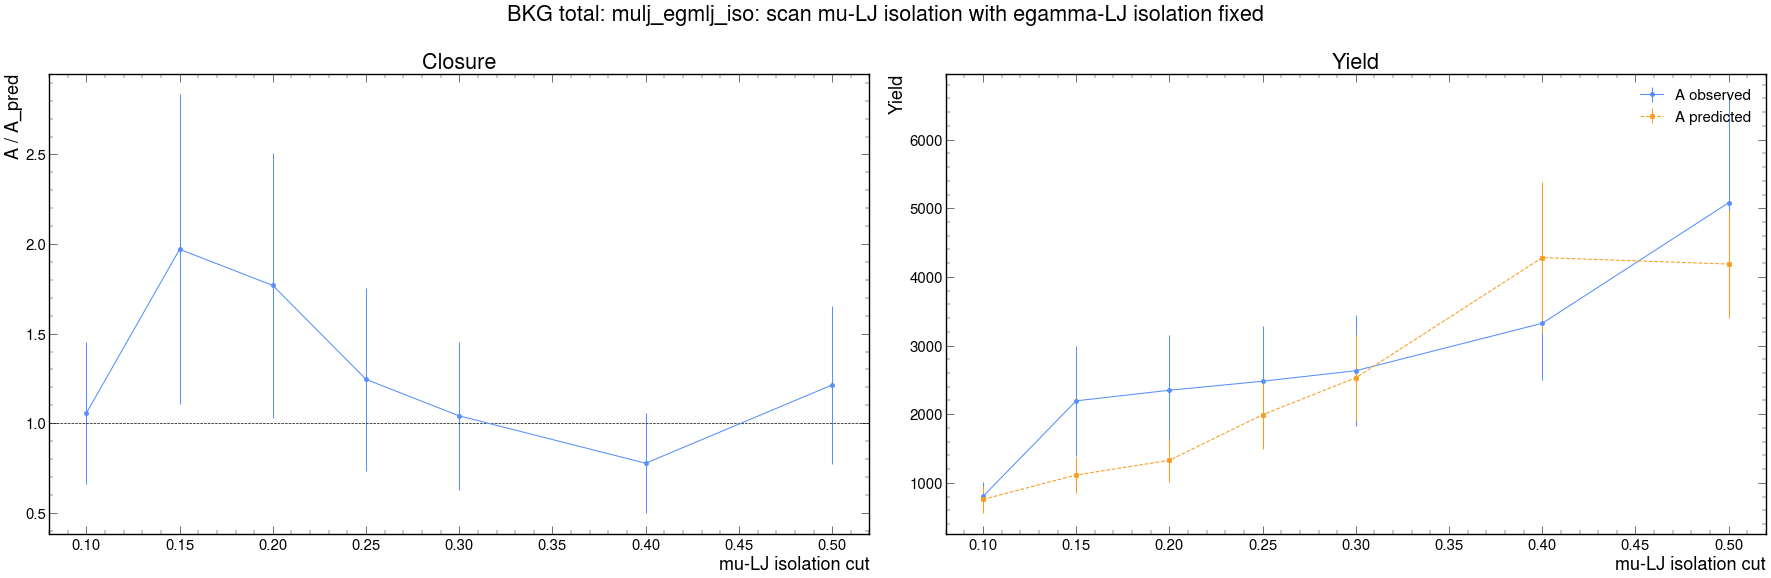


===== mulj_egmlj_iso: scan egamma-LJ isolation with mu-LJ isolation fixed =====

--- TTJets ---
cut      A          A_pred     A/A_pred
0.050       203.778    250.237      0.814
0.100       359.037    512.241      0.701
0.150       588.691    775.400      0.759
0.200       621.037    914.690      0.679
0.250       650.148    976.322      0.666
0.300       679.259   1009.302      0.673
0.400       724.543   1175.058      0.617
0.500       750.420   1188.807      0.631


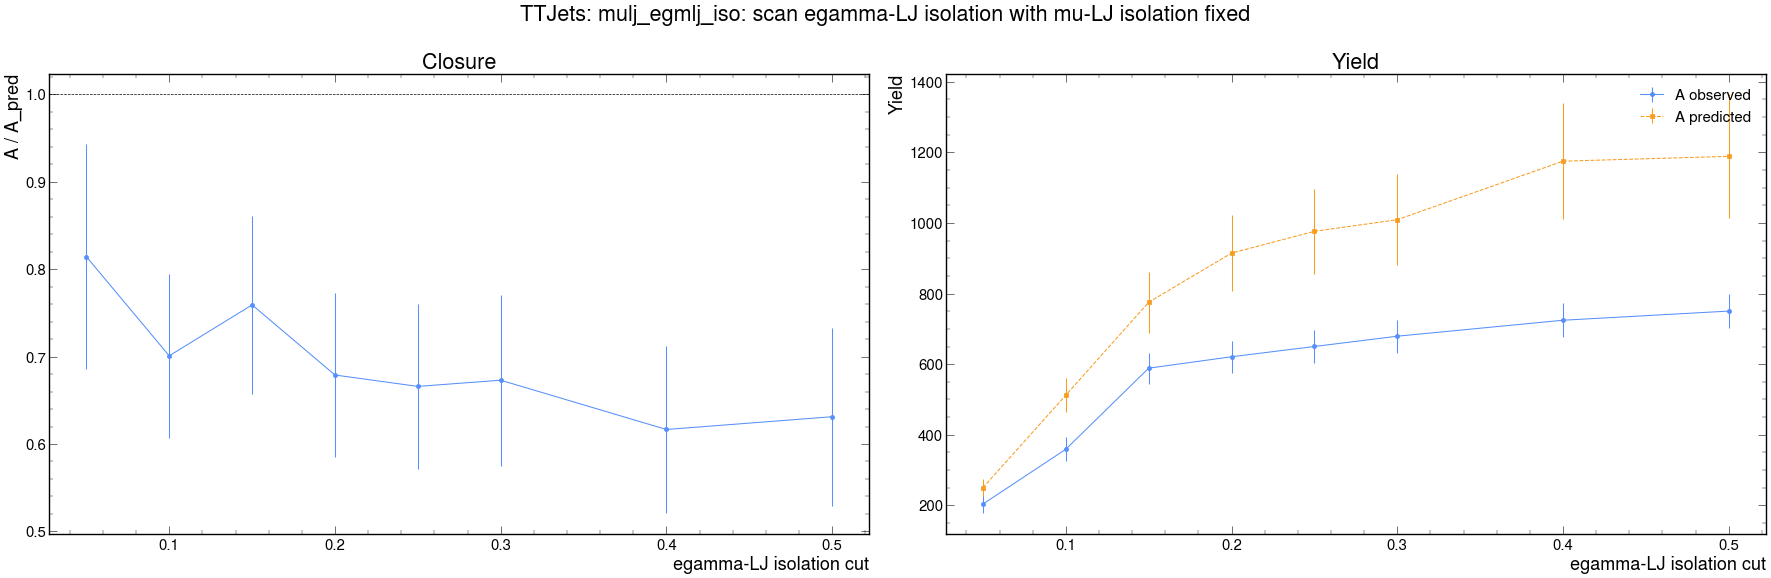


--- QCD ---
cut      A          A_pred     A/A_pred
0.050      1395.278    839.101      1.663
0.100      1865.680   1440.925      1.295
0.150      3395.288   2861.057      1.187
0.200      4439.433   3374.697      1.316
0.250      4999.618   3683.391      1.357
0.300      6013.655   4081.175      1.474
0.400      7218.727   5234.980      1.379
0.500      9918.730   5126.732      1.935


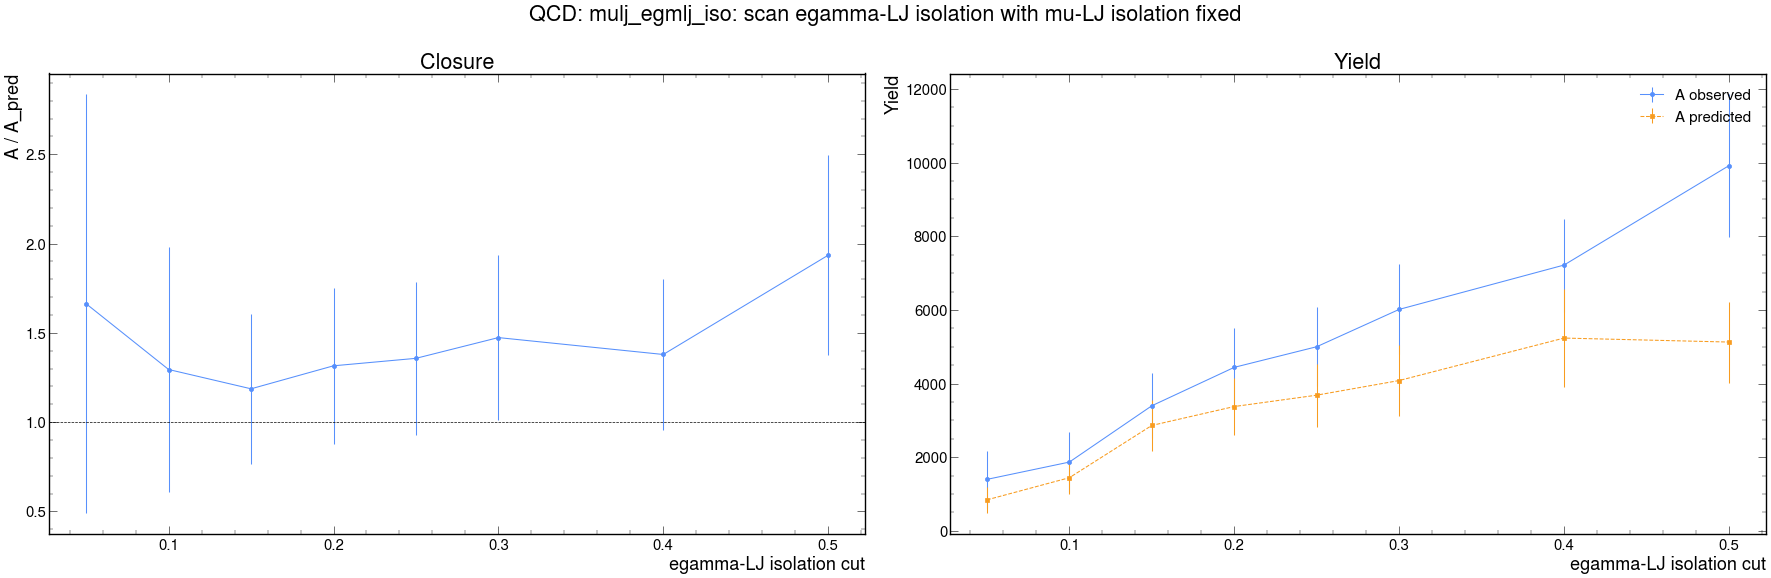


--- DY ---
cut      A          A_pred     A/A_pred
0.050       183.601      0.326    563.597
0.100       229.664      0.766    299.940
0.150       413.473 378779.932      0.001
0.200       459.468 384301.915      0.001
0.250       459.599 422730.134      0.001
0.300       505.552 447513.306      0.001
0.400       643.341 482693.709      0.001
0.500       735.177 451346.709      0.002


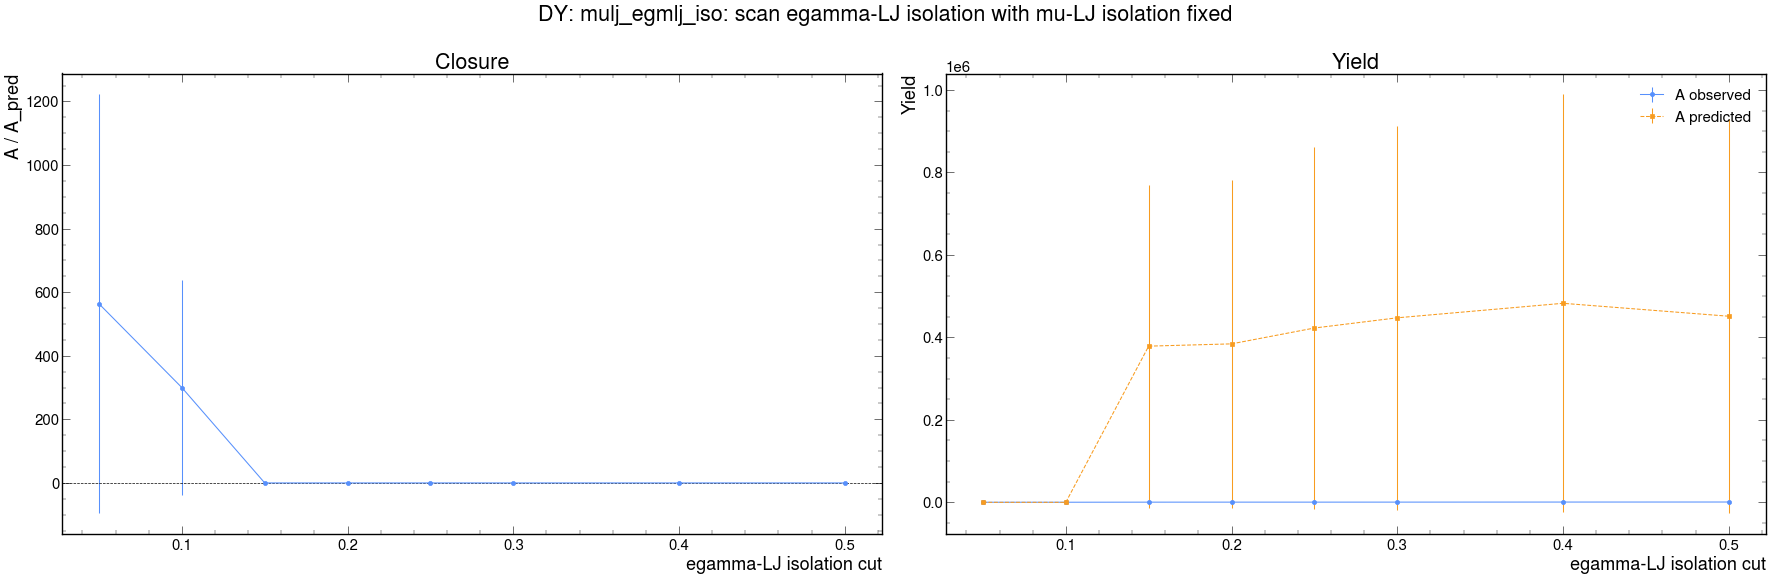


--- Diboson ---
cut      A          A_pred     A/A_pred
0.050        14.327     17.388      0.824
0.100        25.816     34.397      0.751
0.150        36.895     75.230      0.490
0.200        39.552    127.142      0.311
0.250        40.949    109.104      0.375
0.300        42.159    145.090      0.291
0.400        43.979    108.625      0.405
0.500        44.983    186.138      0.242


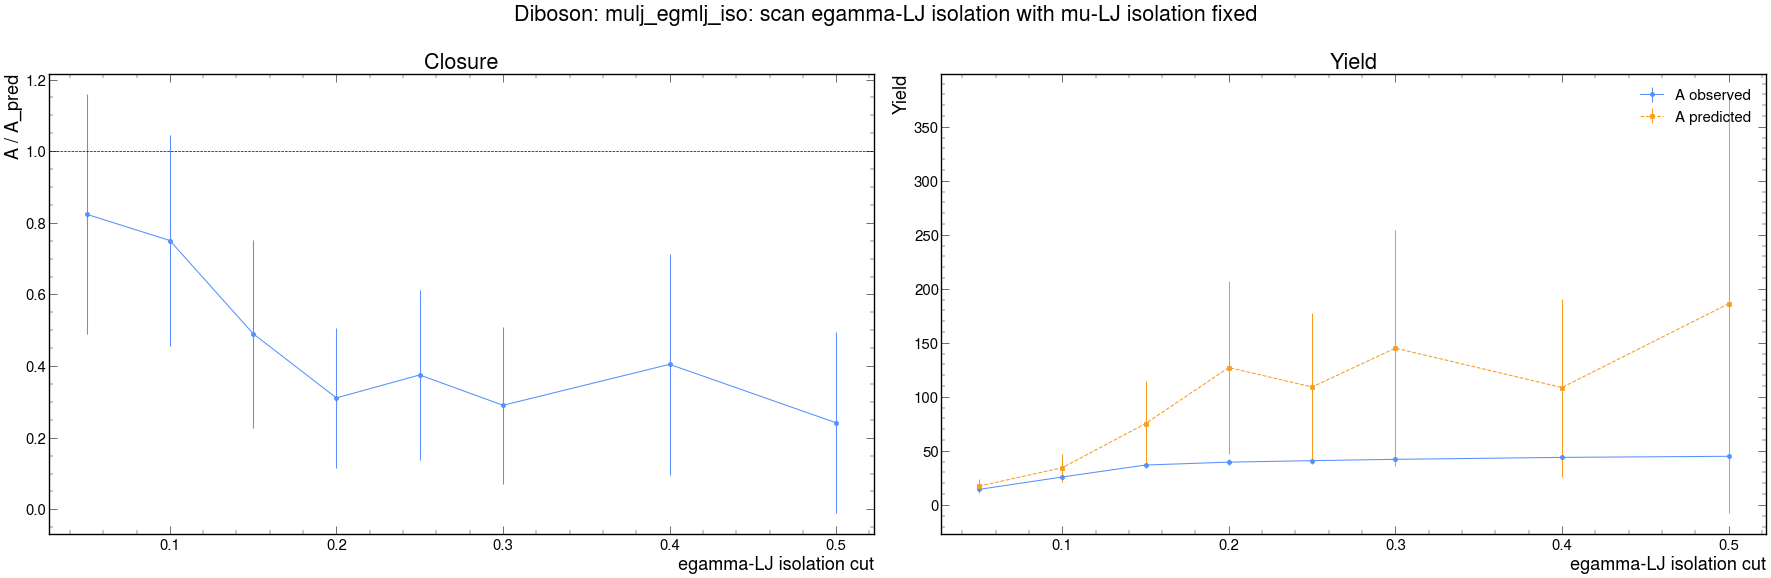


--- BKG total ---
cut      A          A_pred     A/A_pred
0.050      1796.983   1138.554      1.578
0.100      2480.198   1992.903      1.245
0.150      4434.347   3715.235      1.194
0.200      5559.490   4311.684      1.289
0.250      6150.314   4676.988      1.315
0.300      7240.625   5115.331      1.415
0.400      8630.591   6382.908      1.352
0.500     11449.310   6276.192      1.824


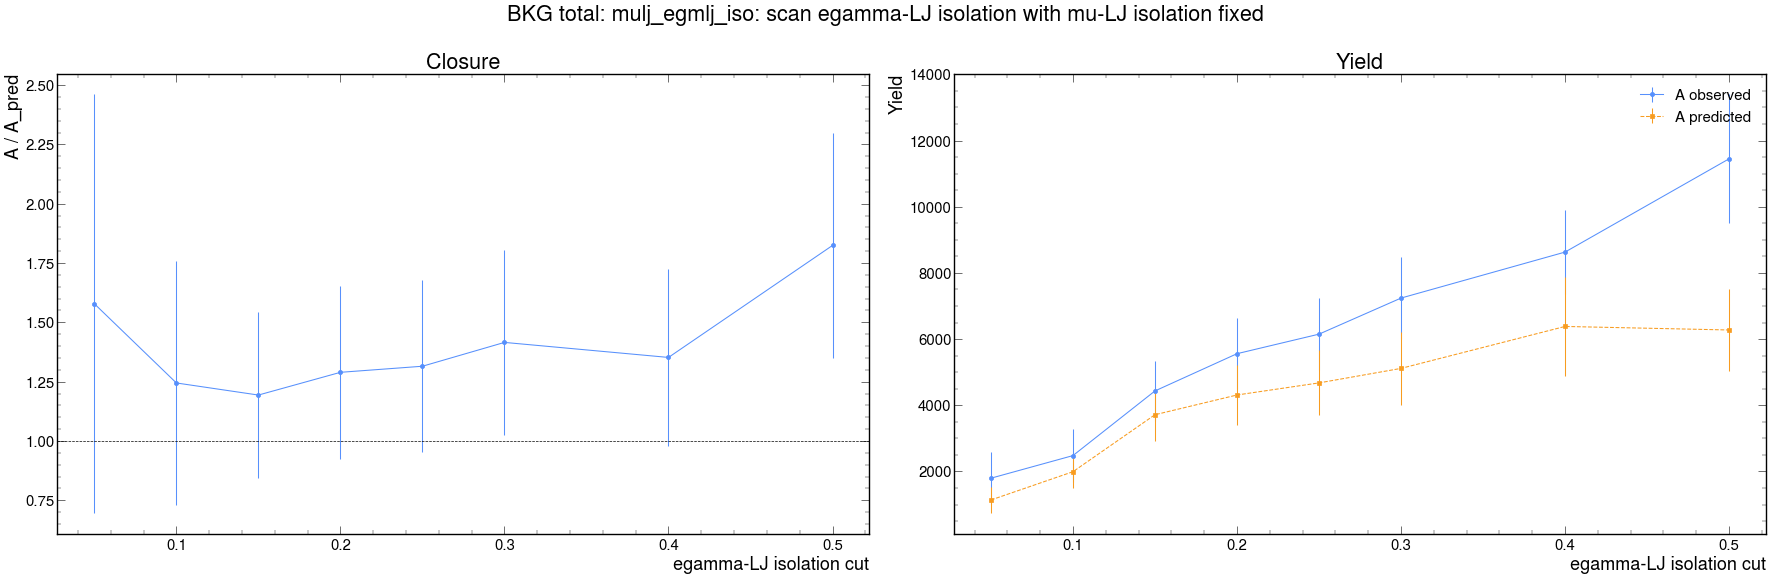


===== mulj_mulj_iso: scan leading mu-LJ isolation with subleading fixed =====

--- TTJets ---
cut      A          A_pred     A/A_pred
0.100        38.815     19.265      2.015
0.150        42.049     27.631      1.522
0.200        48.519     24.761      1.959
0.250        51.753     25.877      2.000
0.300        54.988     29.111      1.889
0.400        61.457     31.293      1.964
0.500        64.691     37.108      1.743


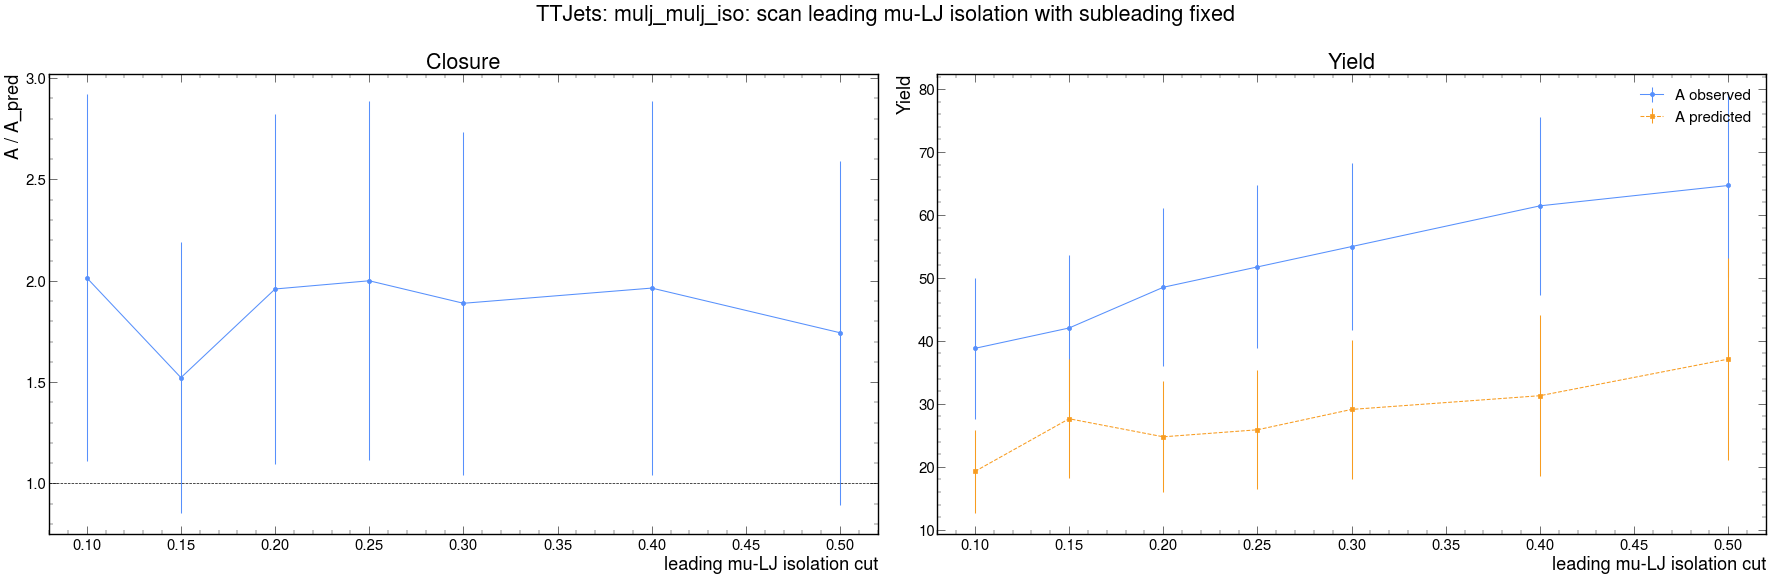


--- QCD ---
cut      A          A_pred     A/A_pred
0.100        81.592    231.939      0.352
0.150       161.495    611.148      0.264
0.200       261.702    613.919      0.426
0.250       394.140    813.153      0.485
0.300       732.155    839.784      0.872
0.400      1236.317   1388.780      0.890
0.500      1447.324   1925.001      0.752


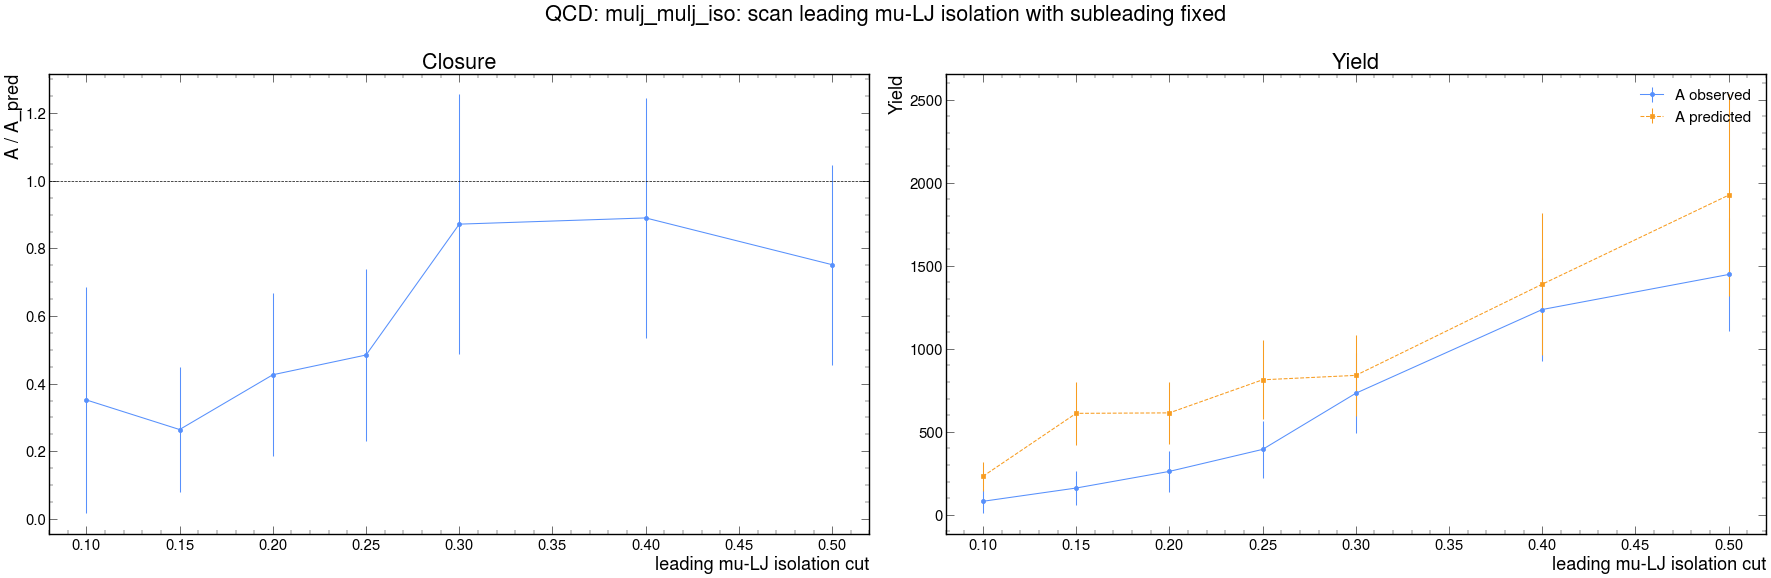


--- DY ---
cut      A          A_pred     A/A_pred
0.100       139.557      1.415     98.641
0.150       139.978      1.262    110.936
0.200       140.026      1.067    131.185
0.250       140.052      0.869    161.228
0.300       140.059      0.762    183.734
0.400       140.083      0.627    223.344
0.500       140.090      0.535    261.744


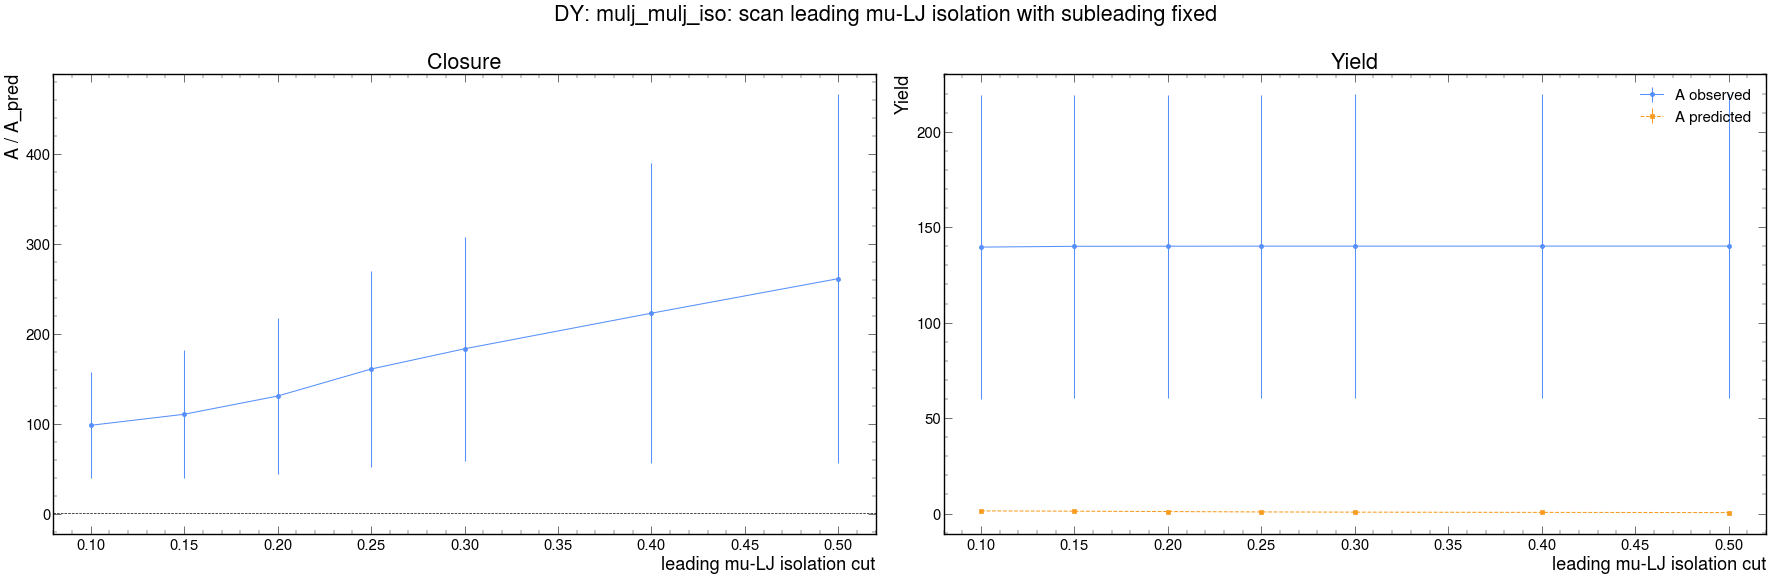


--- Diboson ---
cut      A          A_pred     A/A_pred
0.100         8.881      3.514      2.528
0.150        10.278      0.788     13.050
0.200        10.278      0.788     13.050
0.250        10.278      0.788     13.050
0.300        10.278      0.788     13.050
0.400        10.475      0.403     25.960
0.500        10.475      0.403     25.960


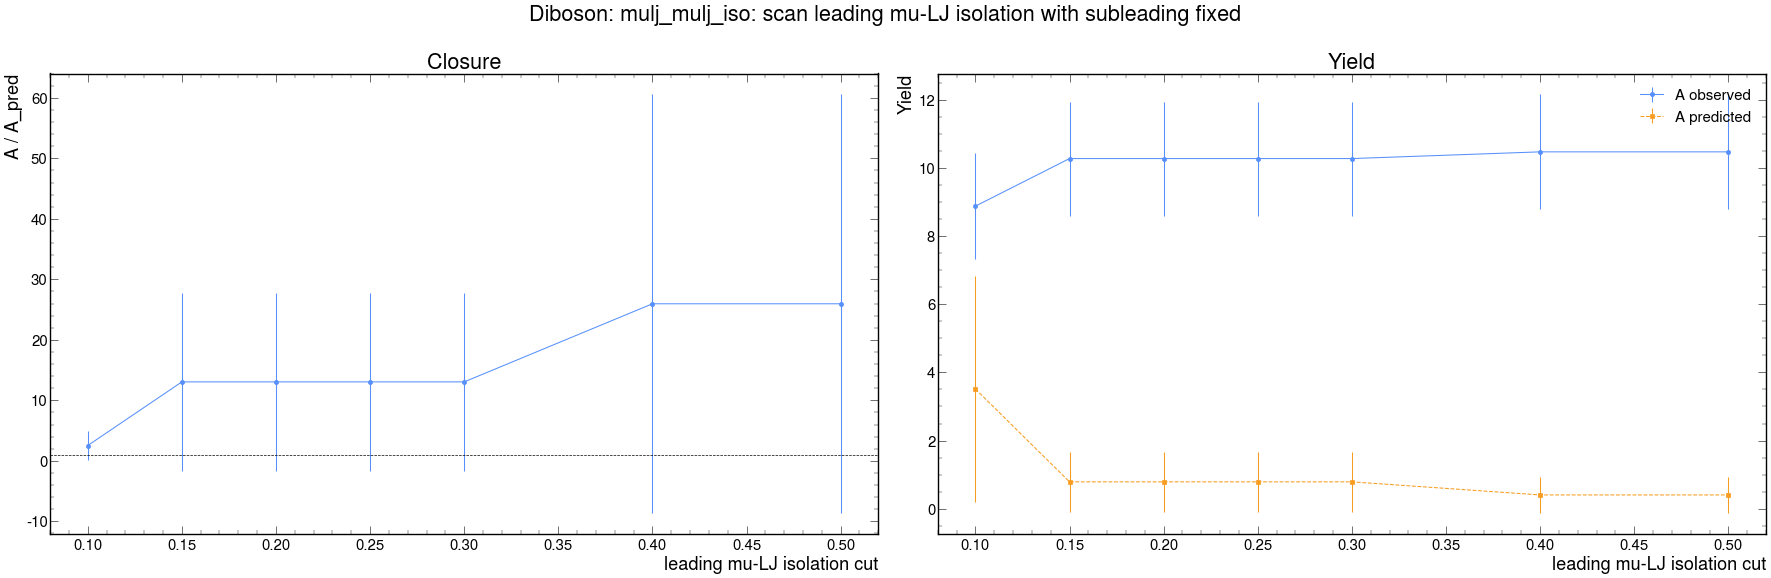


--- BKG total ---
cut      A          A_pred     A/A_pred
0.100       268.845    244.525      1.099
0.150       353.801    631.245      0.560
0.200       460.524    632.891      0.728
0.250       596.223    834.316      0.715
0.300       937.479    862.429      1.087
0.400      1448.331   1417.079      1.022
0.500      1662.580   1960.504      0.848


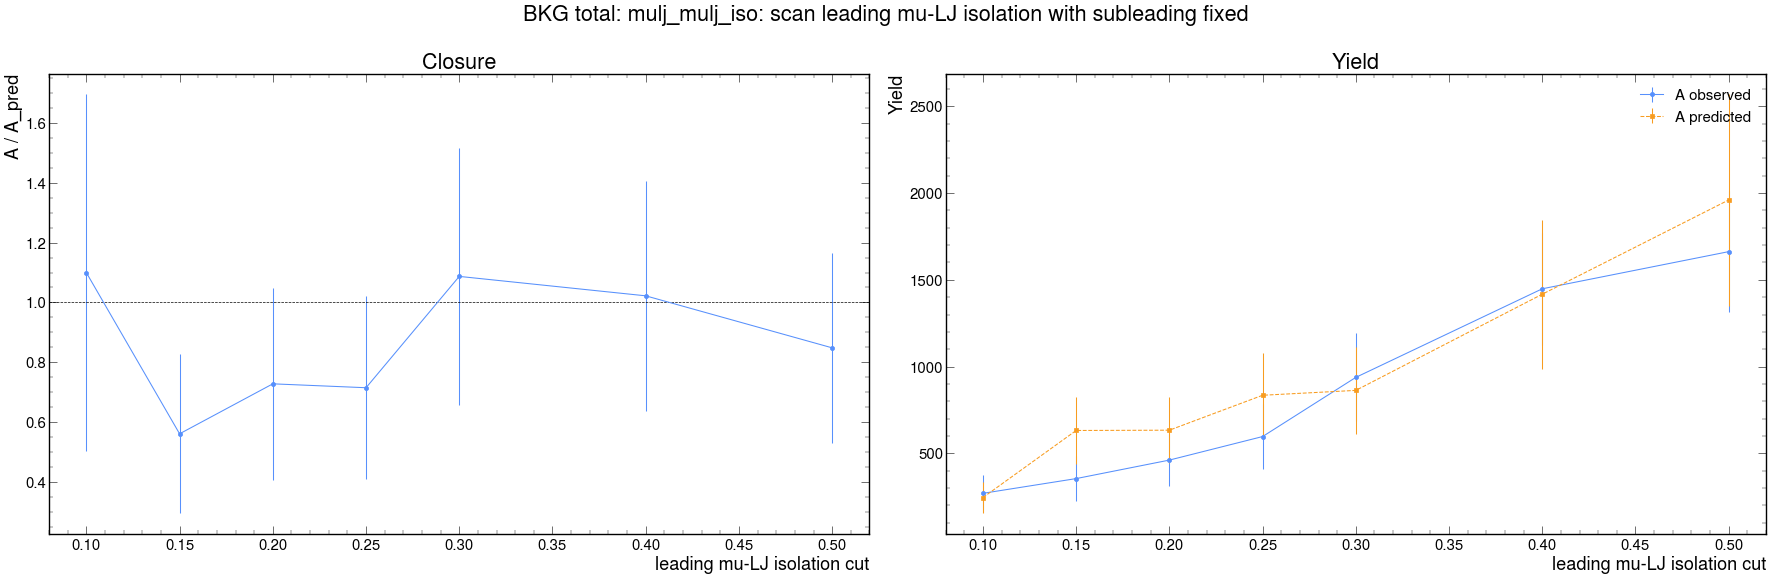


===== mulj_mulj_iso: scan subleading mu-LJ isolation with leading fixed =====

--- TTJets ---
cut      A          A_pred     A/A_pred
0.100        25.877     18.421      1.405
0.150        42.049     19.184      2.192
0.200        45.284     24.259      1.867
0.250        51.753     25.877      2.000
0.300        58.222     27.314      2.132
0.400        84.099     36.389      2.311
0.500        93.802     60.462      1.551


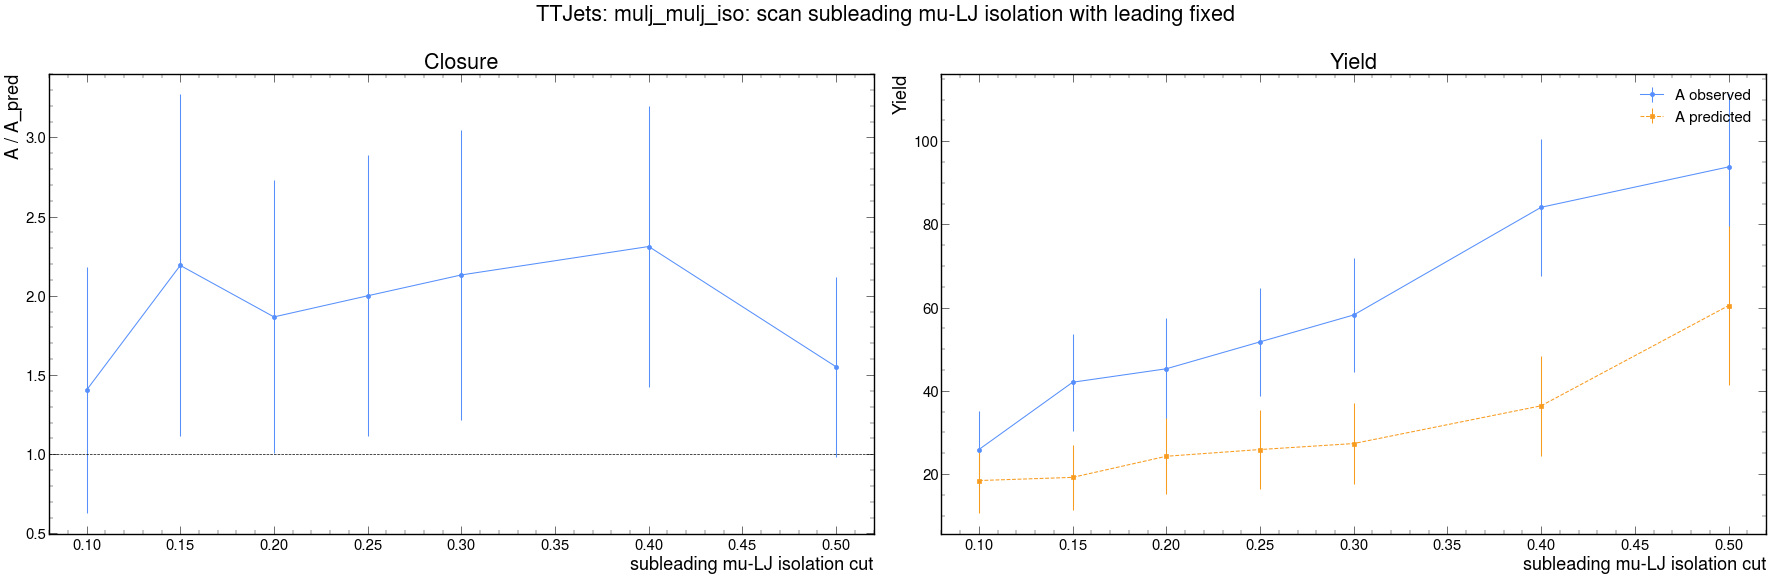


--- QCD ---
cut      A          A_pred     A/A_pred
0.100       236.783    260.973      0.907
0.150       252.189    439.784      0.573
0.200       371.265    697.113      0.533
0.250       394.140    813.153      0.485
0.300       792.830    881.324      0.900
0.400      1227.606   2081.596      0.590
0.500      2545.348   2095.457      1.215


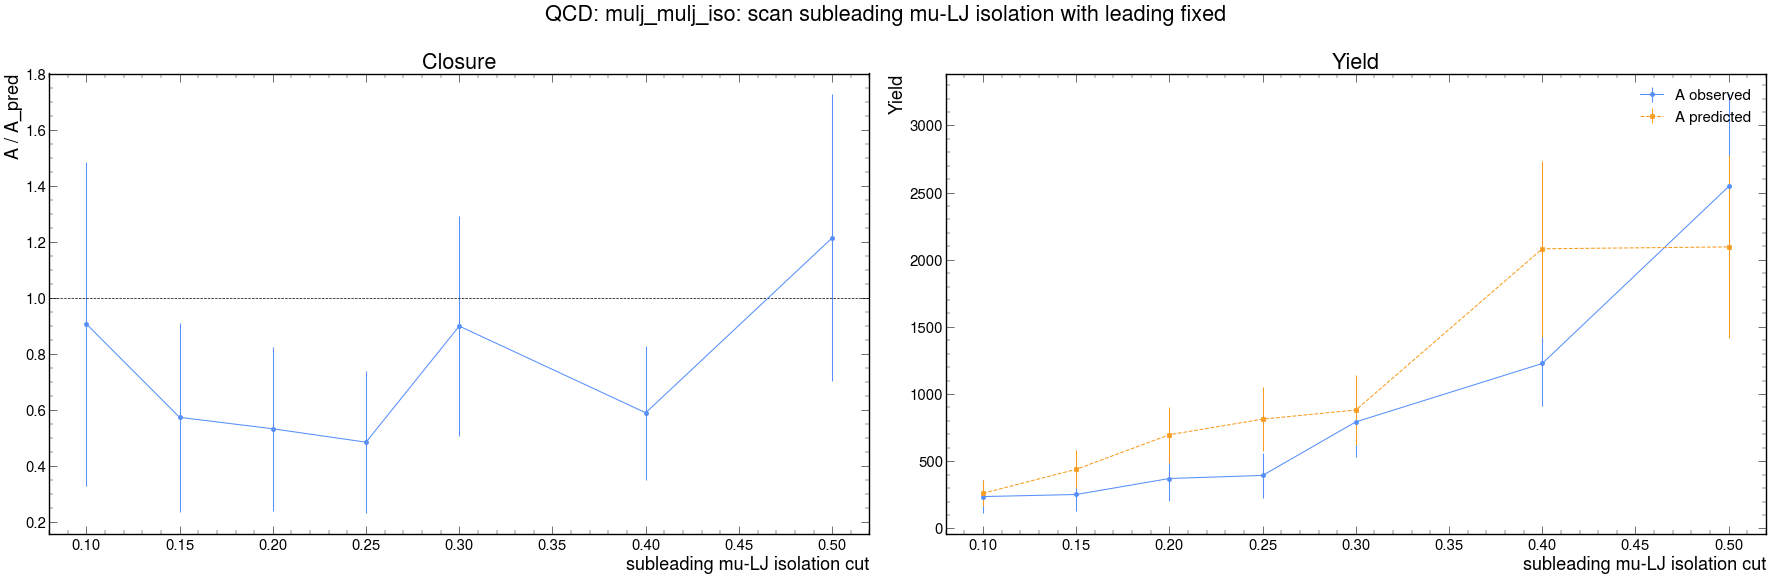


--- DY ---
cut      A          A_pred     A/A_pred
0.100        47.522     92.725      0.512
0.150        94.017    116.934      0.804
0.200        94.135    138.337      0.680
0.250       140.052      0.869    161.228
0.300       140.097      0.853    164.239
0.400       140.152      0.615    227.804
0.500       140.181      0.430    326.061


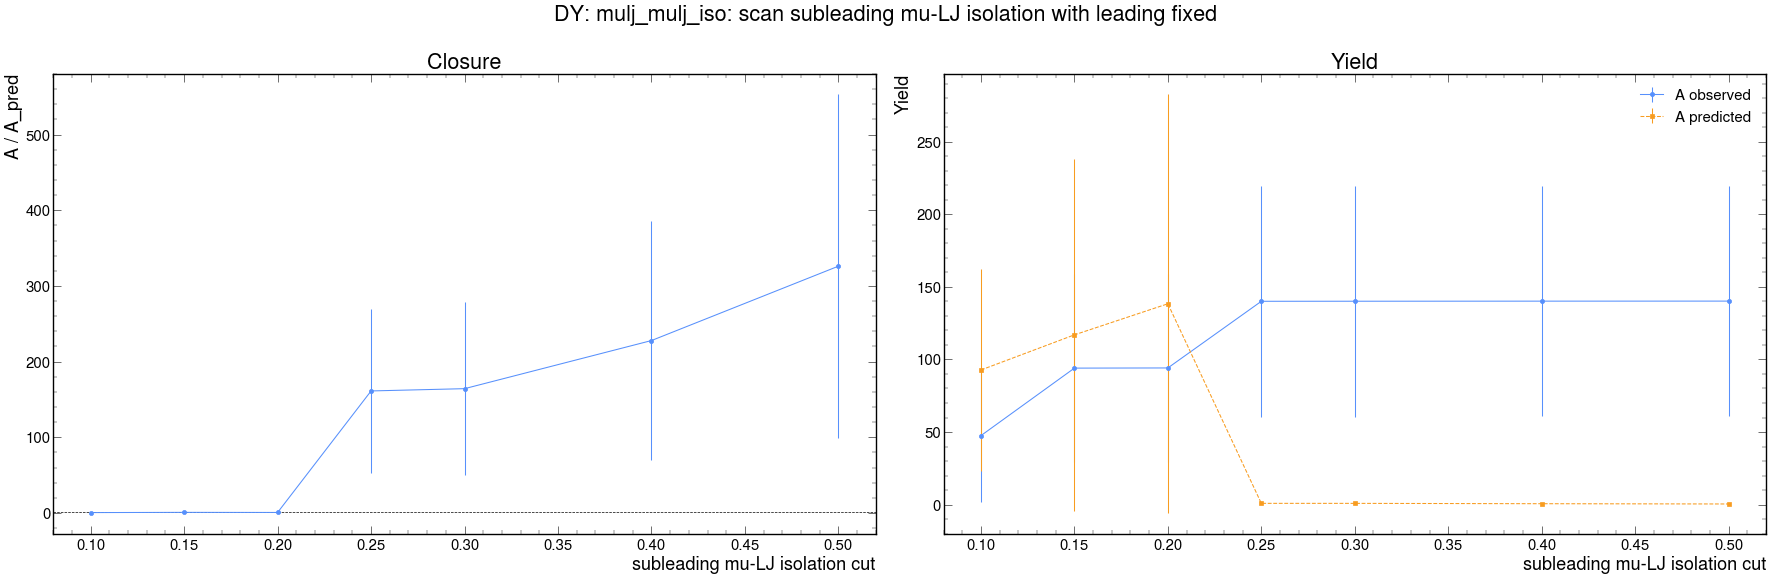


--- Diboson ---
cut      A          A_pred     A/A_pred
0.100         6.648      1.503      4.424
0.150         9.874      0.410     24.080
0.200        10.278      0.788     13.050
0.250        10.278      0.788     13.050
0.300        10.278      0.788     13.050
0.400        10.878      0.202     53.921
0.500        10.878      0.202     53.921


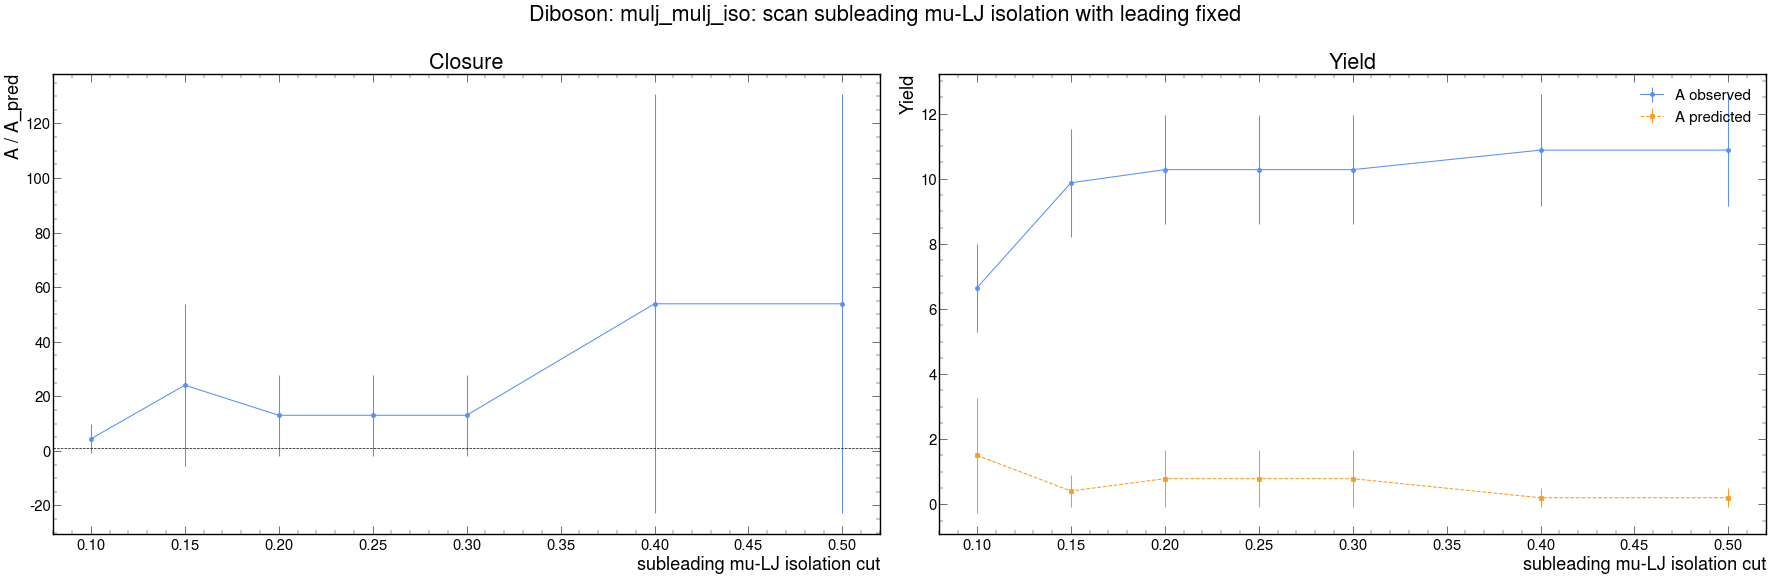


--- BKG total ---
cut      A          A_pred     A/A_pred
0.100       316.830    276.027      1.148
0.150       398.130    456.831      0.872
0.200       520.962    721.487      0.722
0.250       596.223    834.316      0.715
0.300      1001.426    903.986      1.108
0.400      1462.735   2118.411      0.690
0.500      2790.209   2146.635      1.300


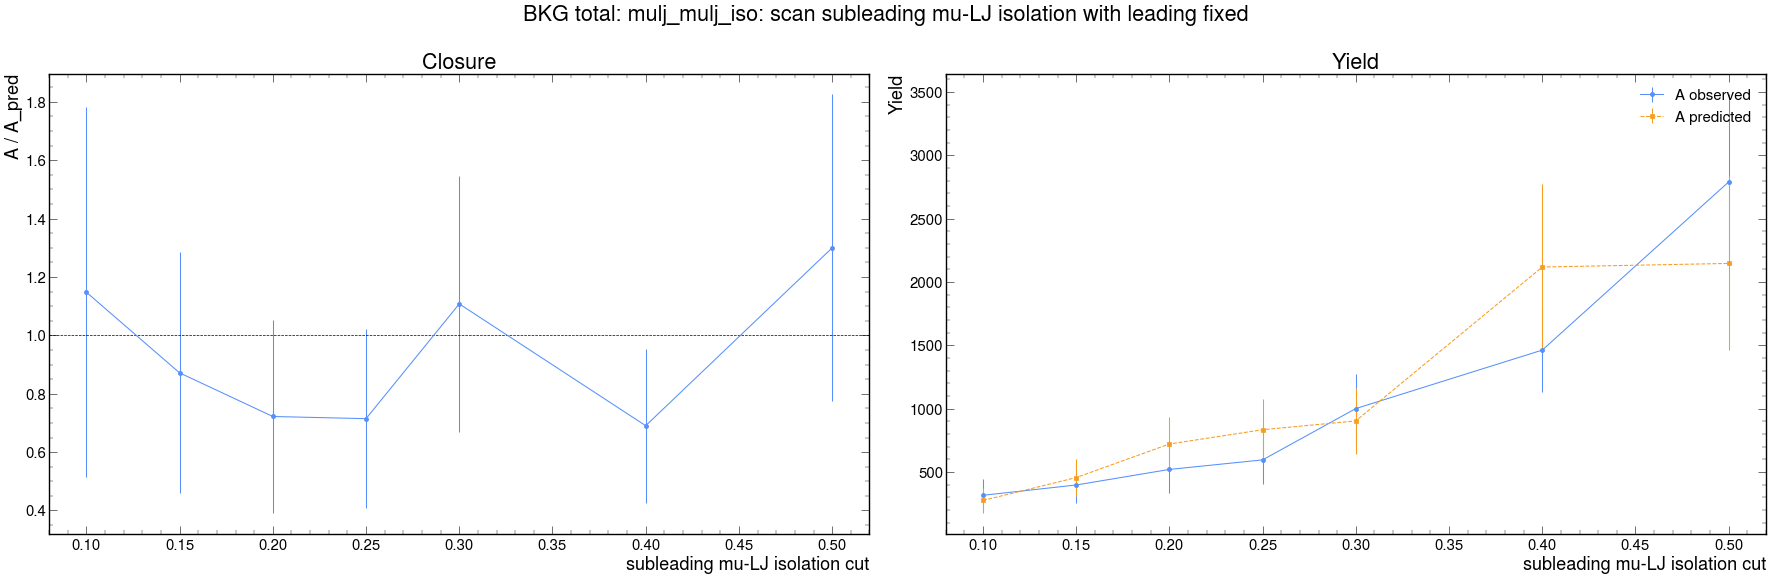

In [30]:
scan_definitions = [
    {
        "name": "mulj_egmlj_iso: scan mu-LJ isolation with egamma-LJ isolation fixed",
        "hist": "mulj_egmlj_iso",
        "scan_values": scan_values_default,
        "fixed_cut": 0.10,
        "scan_axis": "x",
        "xlabel": "mu-LJ isolation cut",
    },
    {
        "name": "mulj_egmlj_iso: scan egamma-LJ isolation with mu-LJ isolation fixed",
        "hist": "mulj_egmlj_iso",
        "scan_values": scan_values_egm,
        "fixed_cut": 0.25,
        "scan_axis": "y",
        "xlabel": "egamma-LJ isolation cut",
    },
    {
        "name": "mulj_mulj_iso: scan leading mu-LJ isolation with subleading fixed",
        "hist": "mulj_mulj_iso",
        "scan_values": scan_values_default,
        "fixed_cut": 0.25,
        "scan_axis": "x",
        "xlabel": "leading mu-LJ isolation cut",
    },
    {
        "name": "mulj_mulj_iso: scan subleading mu-LJ isolation with leading fixed",
        "hist": "mulj_mulj_iso",
        "scan_values": scan_values_default,
        "fixed_cut": 0.25,
        "scan_axis": "y",
        "xlabel": "subleading mu-LJ isolation cut",
    },
]

scan_results = {}
for scan_cfg in scan_definitions:
    print()
    print(f"===== {scan_cfg['name']} =====")
    scan_results[scan_cfg["name"]] = {}
    for group in iter_available_groups():
        h2d = group_hist(group, scan_cfg["hist"])
        rows = scan_one_axis_h2d(
            h2d,
            scan_values=scan_cfg["scan_values"],
            fixed_cut=scan_cfg["fixed_cut"],
            scan_axis=scan_cfg["scan_axis"],
        )
        scan_results[scan_cfg["name"]][group] = rows
        print()
        print(f"--- {group} ---")
        print_scan(rows)
        title = f"{group}: {scan_cfg['name']}"
        plot_scan(rows, scan_cfg["xlabel"], title)



===== mulj_mulj_iso: symmetric leading/subleading scan =====

--- TTJets ---
cut      A          A_pred     A/A_pred
0.100        12.938     17.296      0.748
0.150        32.346     22.381      1.445
0.200        42.049     23.519      1.788
0.250        51.753     25.877      2.000
0.300        61.457     31.223      1.968
0.400       100.272     44.263      2.265
0.500       126.148     84.596      1.491


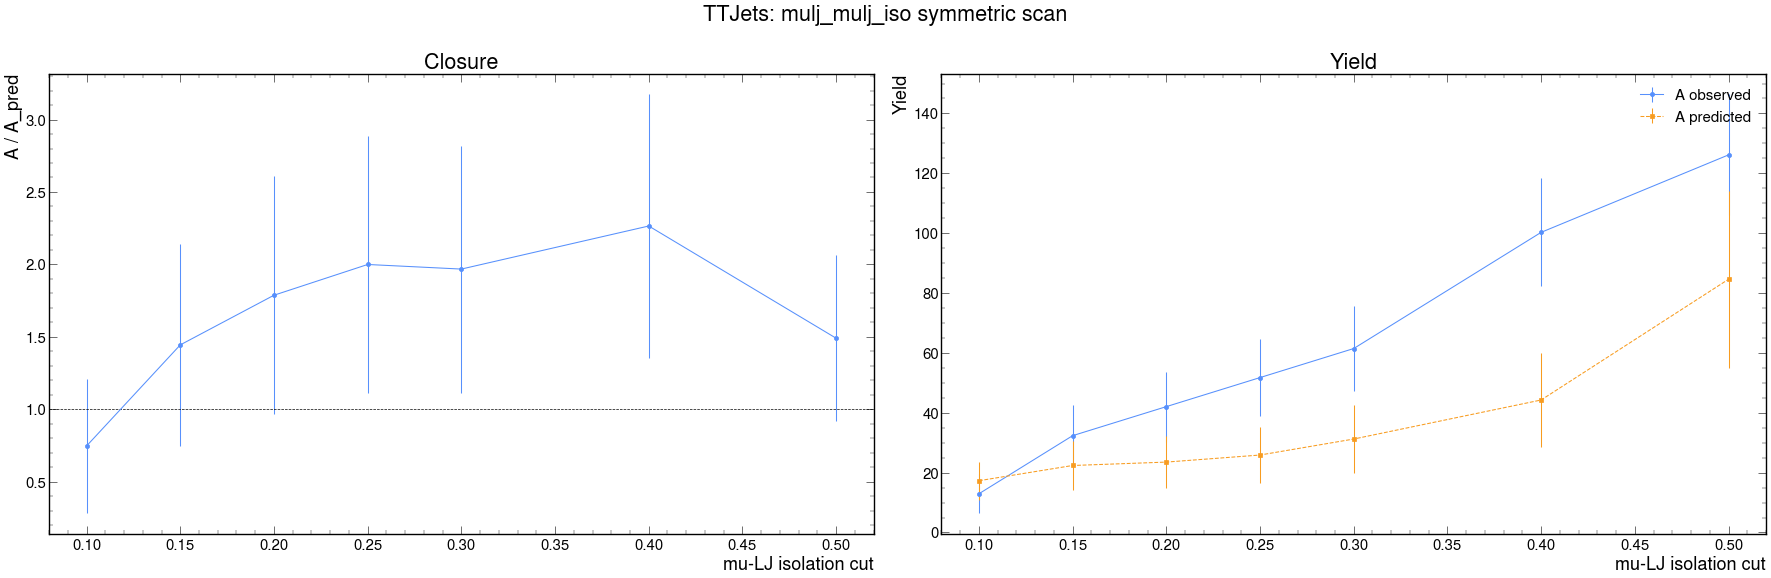


--- QCD ---
cut      A          A_pred     A/A_pred
0.100        79.474     77.305      1.028
0.150       159.269    314.745      0.506
0.200       246.880    528.606      0.467
0.250       394.140    813.153      0.485
0.300      1130.877    936.157      1.208
0.400      4226.016   2079.176      2.033
0.500      6396.683   3738.179      1.711


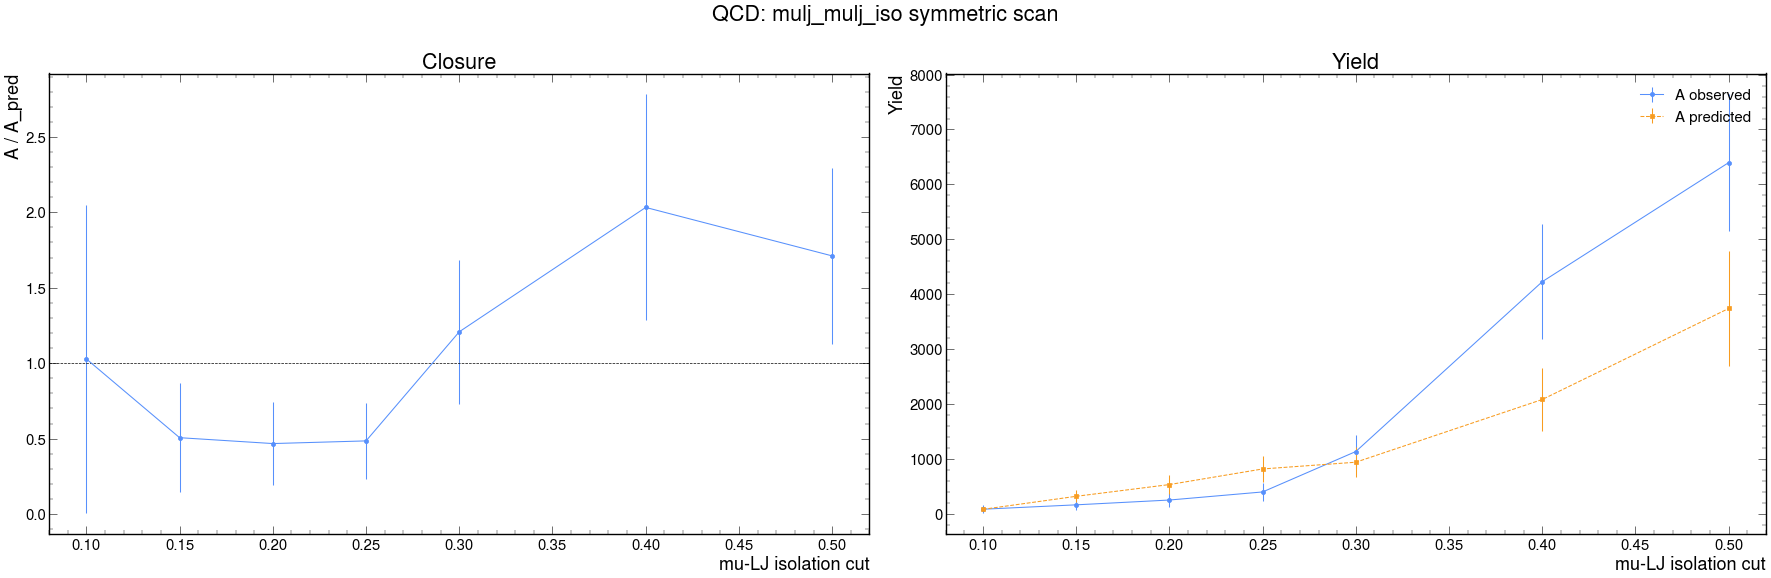


--- DY ---
cut      A          A_pred     A/A_pred
0.100        47.248     94.560      0.500
0.150        93.953    142.971      0.657
0.200        94.110    171.628      0.548
0.250       140.052      0.869    161.228
0.300       140.103      0.753    186.147
0.400       140.185      0.372    377.276
0.500       140.222      0.182    768.507


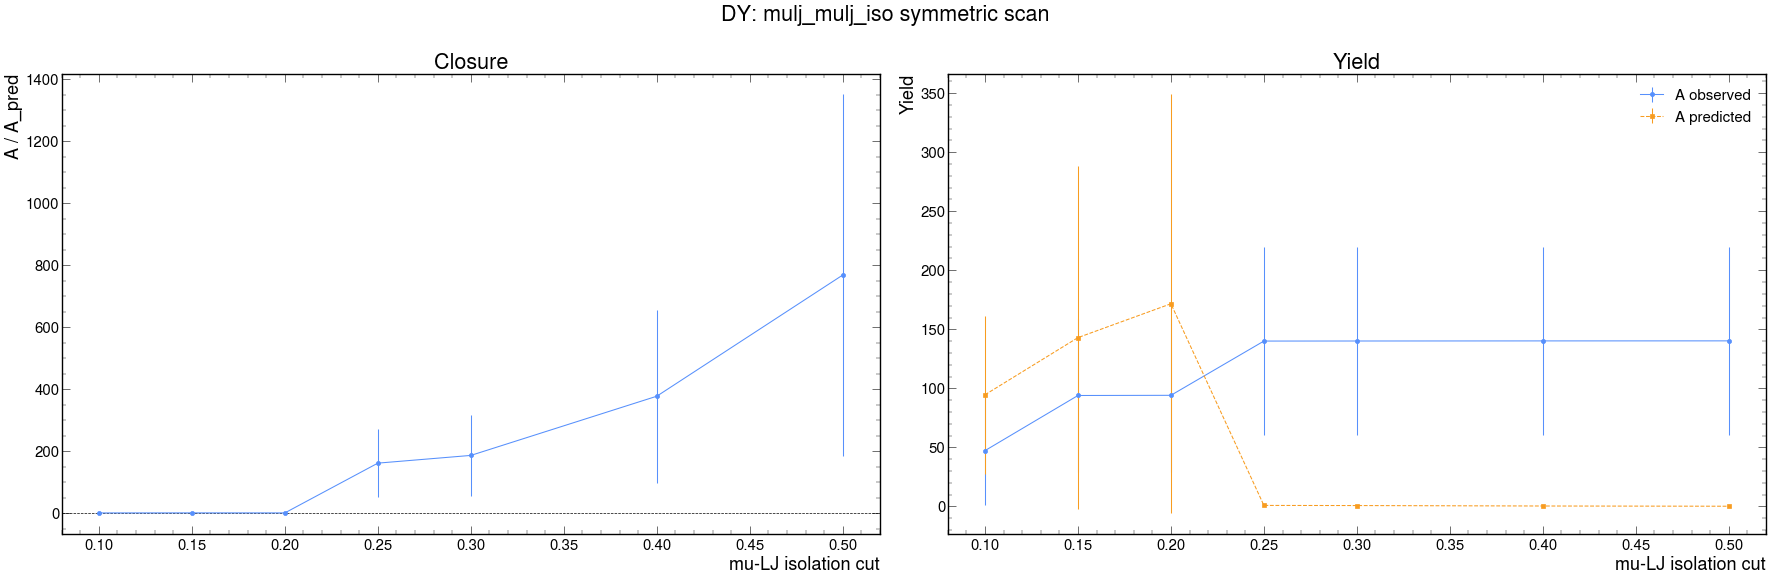


--- Diboson ---
cut      A          A_pred     A/A_pred
0.100         5.842      3.245      1.800
0.150         9.874      0.410     24.080
0.200        10.278      0.788     13.050
0.250        10.278      0.788     13.050
0.300        10.278      0.788     13.050
0.400        11.075      0.103    107.153
0.500        11.075      0.103    107.153


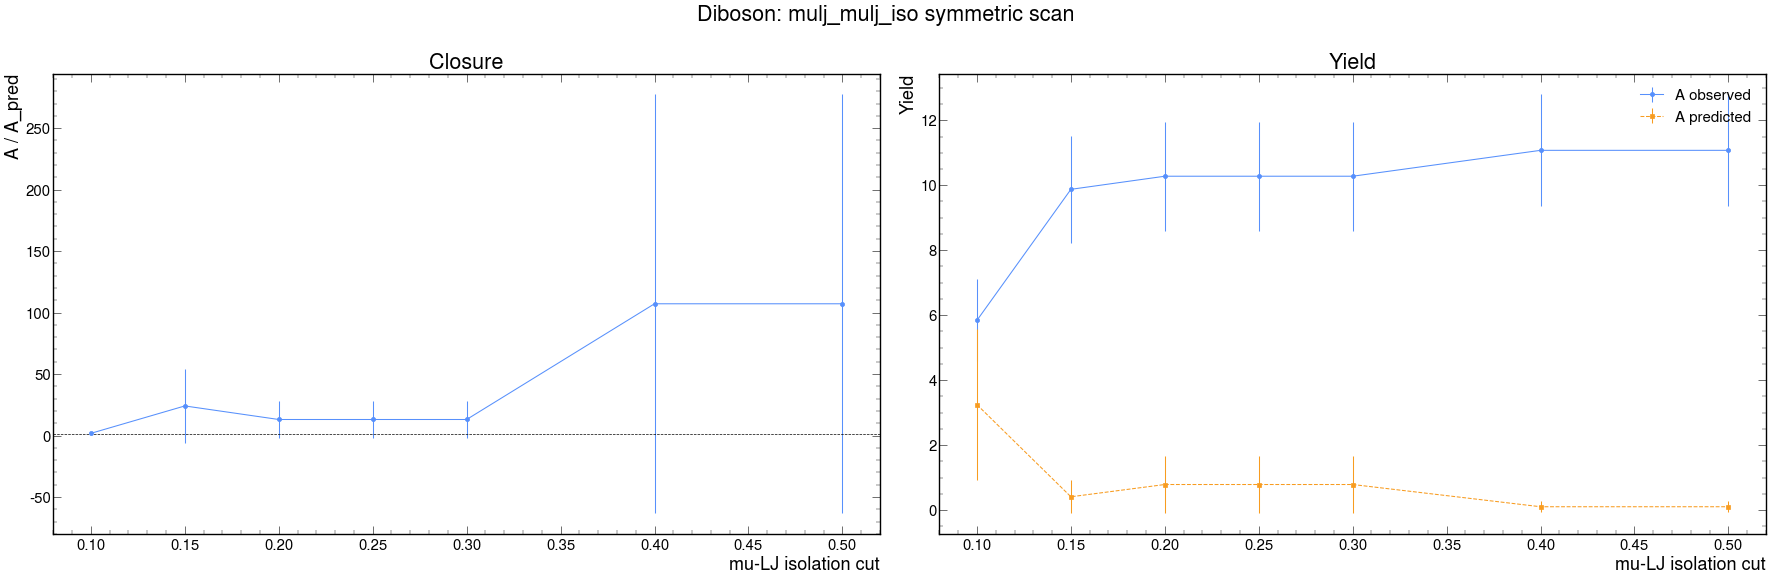


--- BKG total ---
cut      A          A_pred     A/A_pred
0.100       145.503     87.915      1.655
0.150       295.443    331.304      0.892
0.200       393.317    551.031      0.714
0.250       596.223    834.316      0.715
0.300      1342.715    960.881      1.397
0.400      4477.548   2119.228      2.113
0.500      6674.128   3813.330      1.750


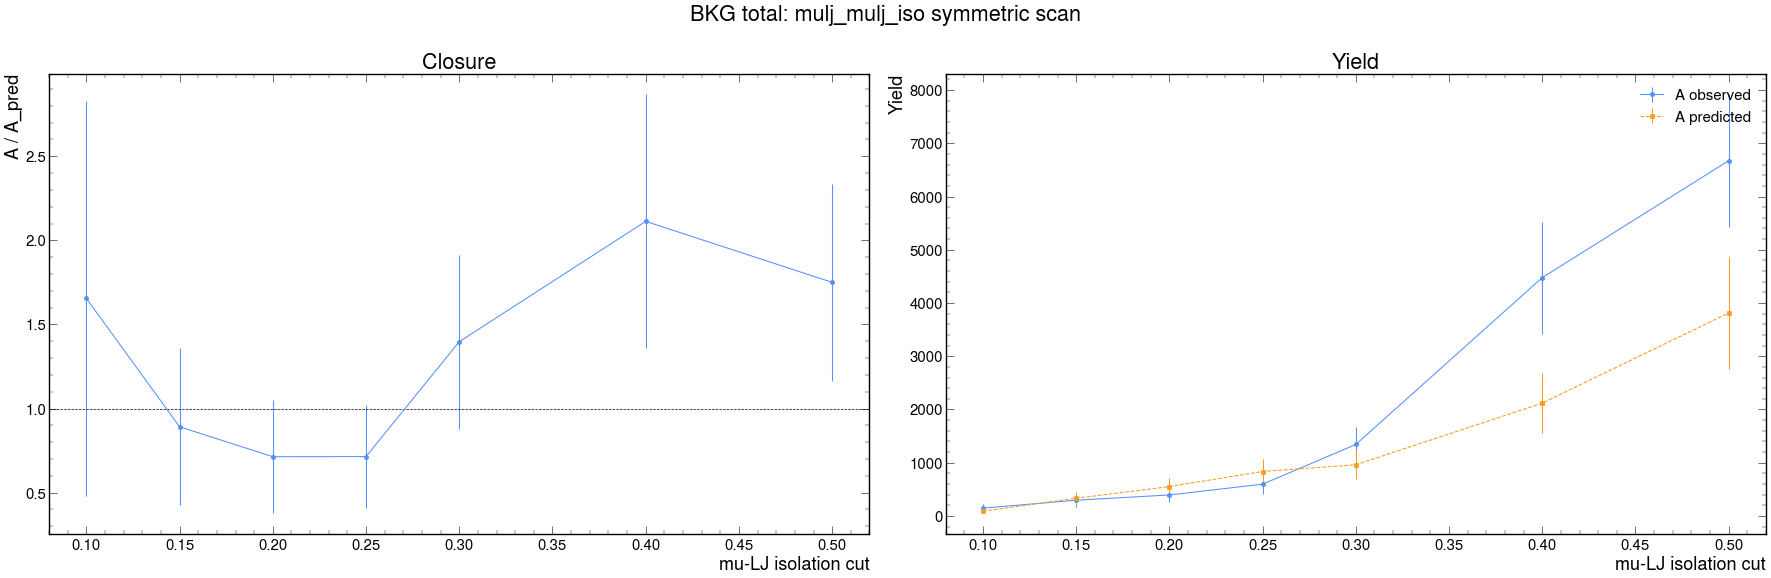

In [32]:
# Symmetric scan for mulj_mulj_iso.
symmetric_scan_results = {}
print()
print("===== mulj_mulj_iso: symmetric leading/subleading scan =====")
for group in iter_available_groups():
    h2d = group_hist(group, "mulj_mulj_iso")
    rows = scan_symmetric_h2d(h2d, scan_values_default)
    symmetric_scan_results[group] = rows
    print()
    print(f"--- {group} ---")
    print_scan(rows)
    plot_scan(rows, "mu-LJ isolation cut", f"{group}: mulj_mulj_iso symmetric scan")


## Correlation Summary and Diagnostics


In [33]:
corr_df = correlation_summary(list(iter_available_groups()), list(hist_configs.keys()))
corr_df


,group,hist,total_yield,weighted_corr
0,TTJets,mulj_egmlj_iso,4596.321722,-0.043995
1,TTJets,mulj_mulj_iso,394.617347,0.117892
2,QCD,mulj_egmlj_iso,76033.149407,0.052708
3,QCD,mulj_mulj_iso,28263.107215,0.163774
4,DY,mulj_egmlj_iso,1240.315477,-0.220800
5,DY,mulj_mulj_iso,140.315476,0.102813
6,Diboson,mulj_egmlj_iso,57.888214,-0.048911
7,Diboson,mulj_mulj_iso,11.901696,0.310795
8,BKG total,mulj_egmlj_iso,81927.674821,0.051492
9,BKG total,mulj_mulj_iso,28809.941735,0.170134



===== Correlation diagnostics: mulj_egmlj_iso =====


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


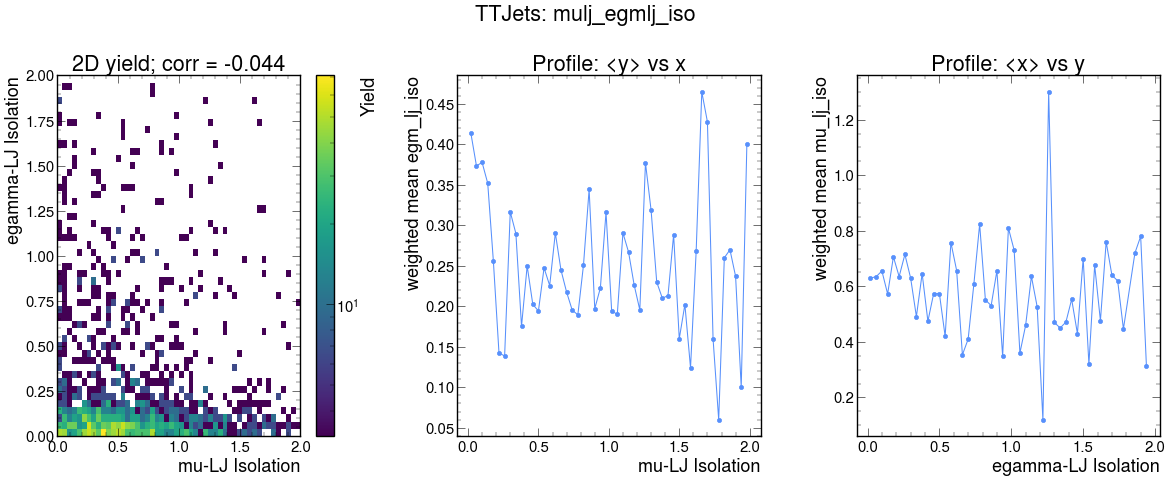

TTJets / mulj_egmlj_iso: weighted Pearson corr = -0.0440


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


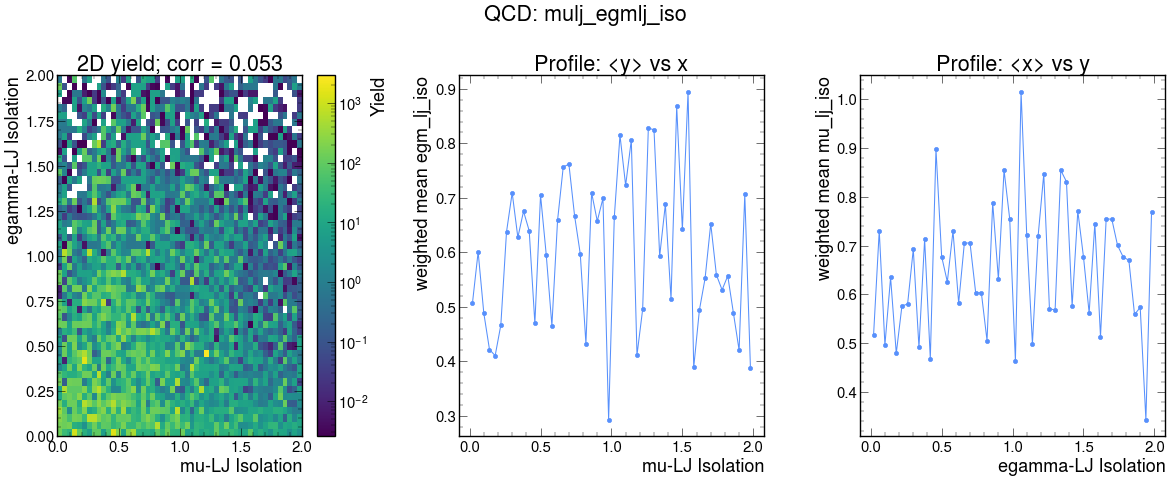

QCD / mulj_egmlj_iso: weighted Pearson corr = 0.0527


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


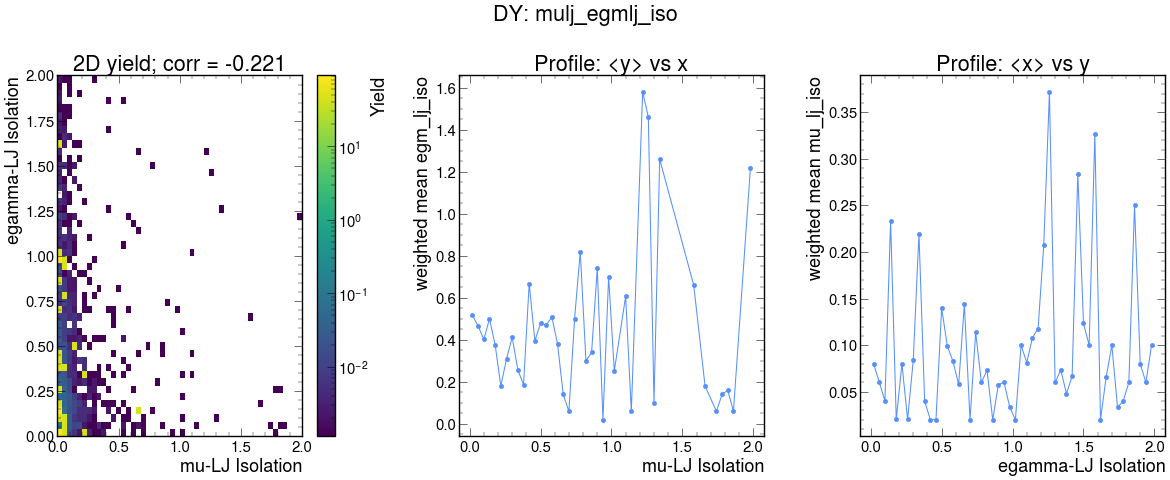

DY / mulj_egmlj_iso: weighted Pearson corr = -0.2208


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


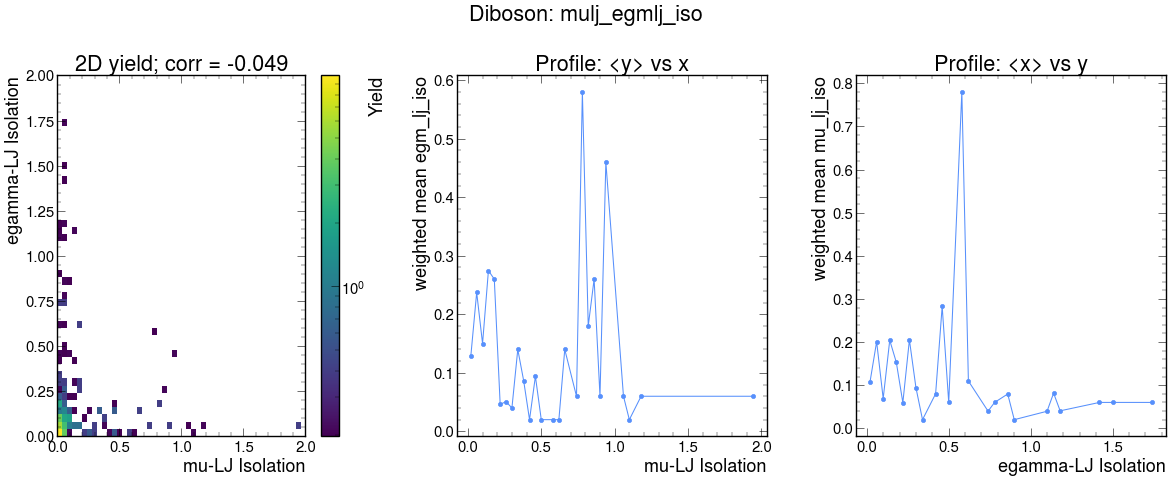

Diboson / mulj_egmlj_iso: weighted Pearson corr = -0.0489


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


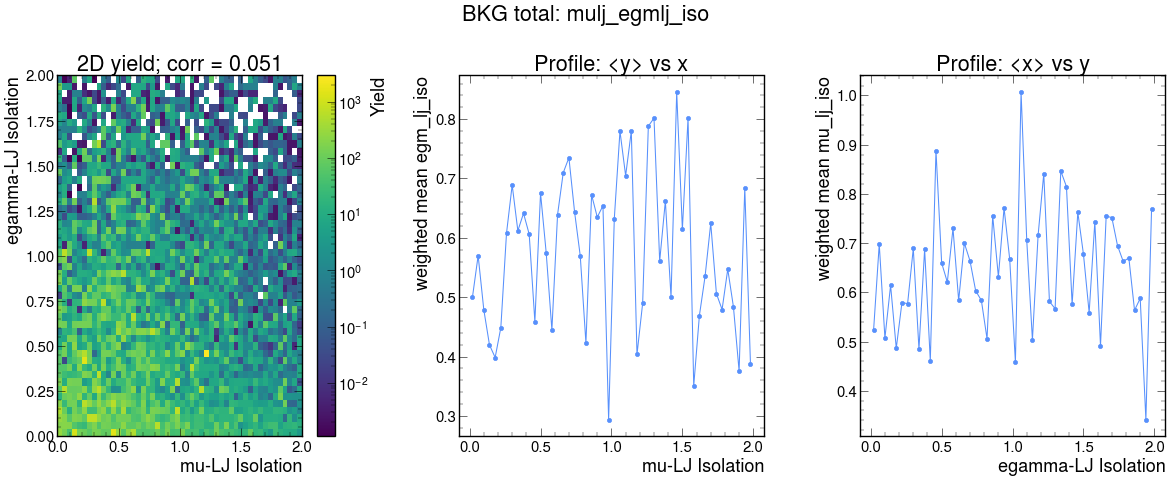

BKG total / mulj_egmlj_iso: weighted Pearson corr = 0.0515

===== Correlation diagnostics: mulj_mulj_iso =====


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


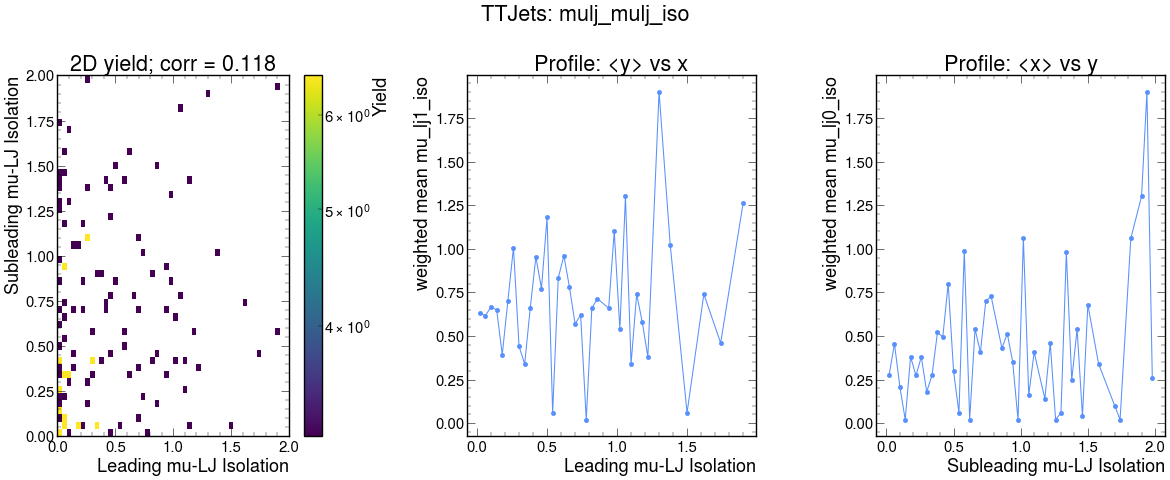

TTJets / mulj_mulj_iso: weighted Pearson corr = 0.1179


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


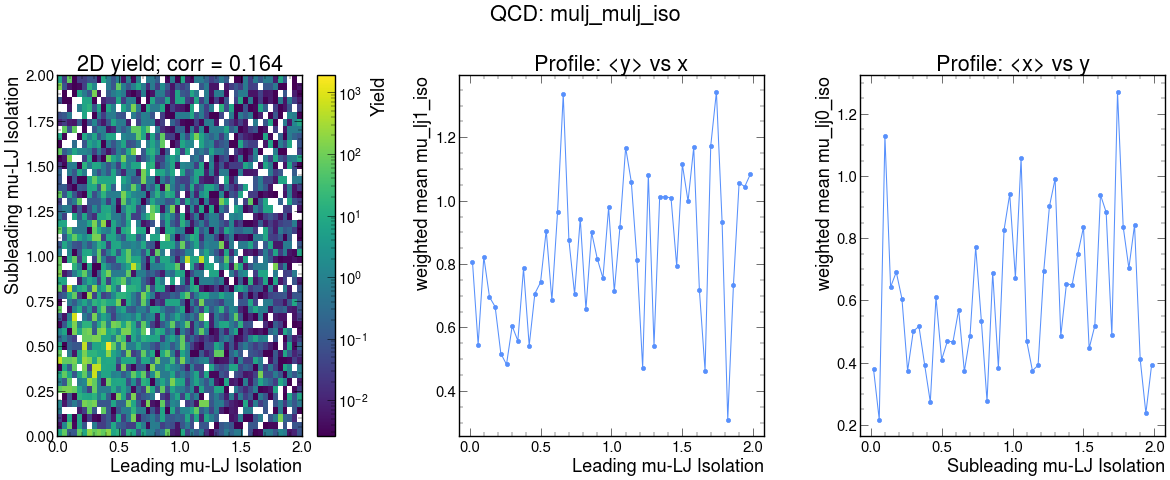

QCD / mulj_mulj_iso: weighted Pearson corr = 0.1638


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


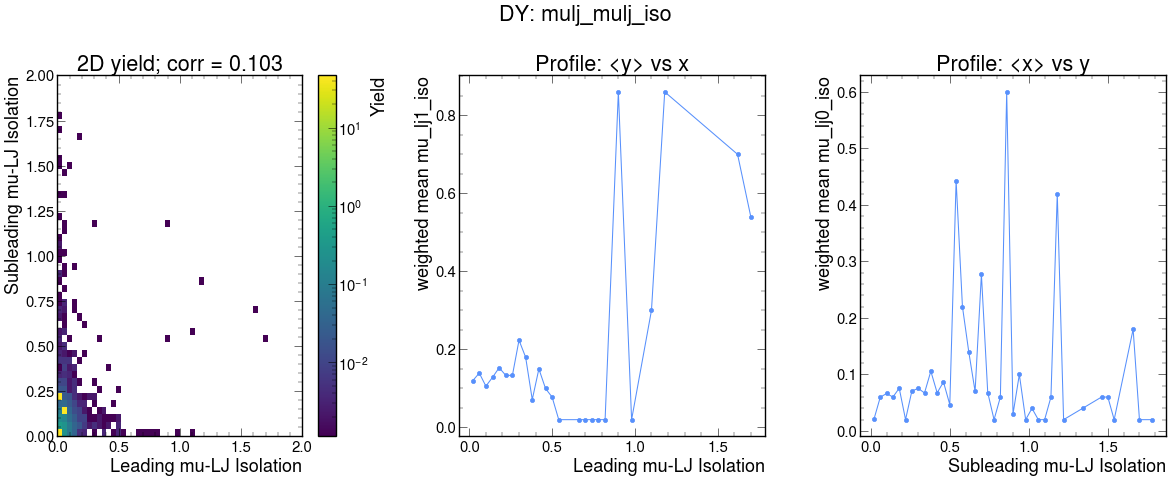

DY / mulj_mulj_iso: weighted Pearson corr = 0.1028


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


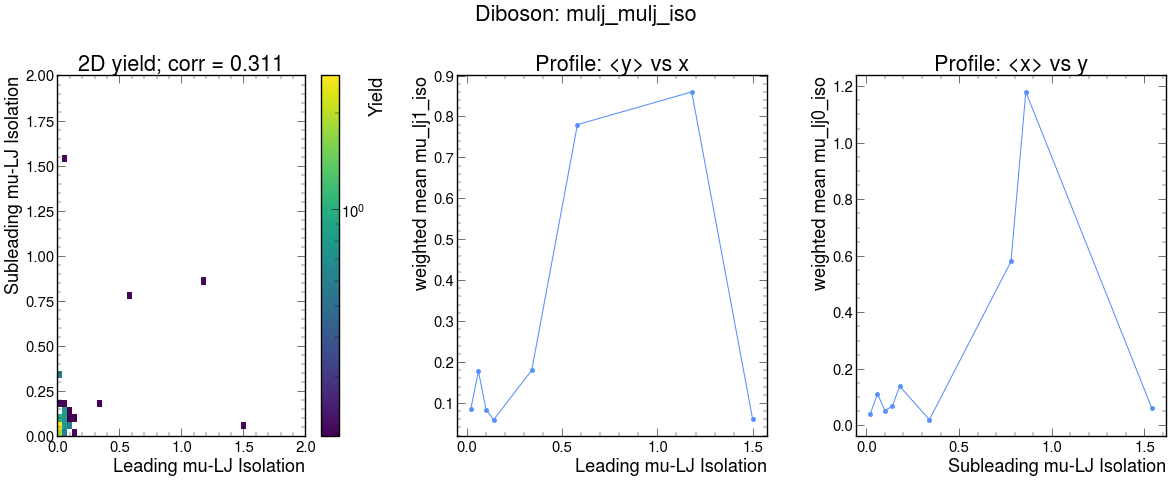

Diboson / mulj_mulj_iso: weighted Pearson corr = 0.3108


/tmp/ipykernel_3724/3701879628.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["y"], weights=g["yield"]))
/tmp/ipykernel_3724/3701879628.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["x"], weights=g["yield"]))


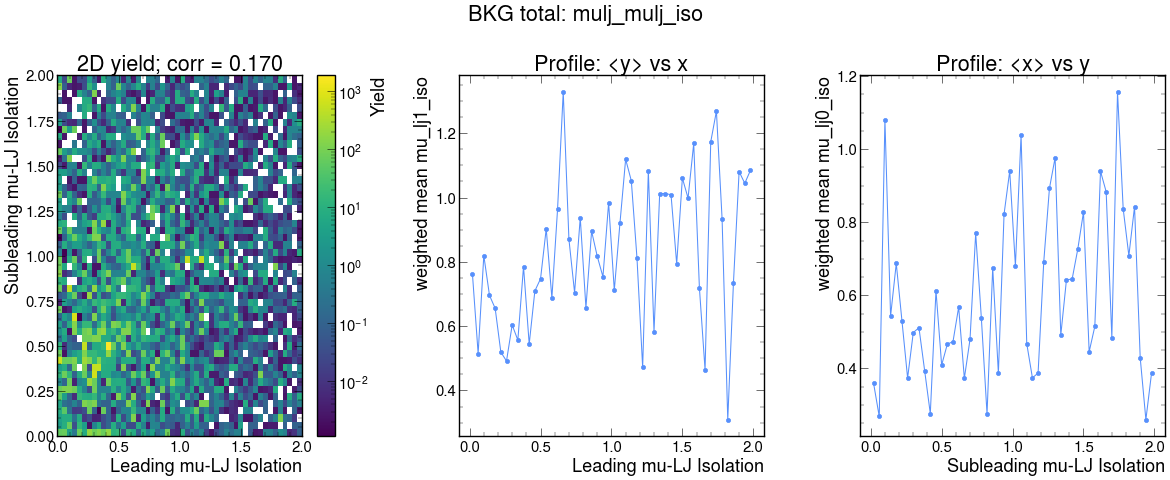

BKG total / mulj_mulj_iso: weighted Pearson corr = 0.1701


In [34]:
for hist_name in hist_configs:
    print()
    print(f"===== Correlation diagnostics: {hist_name} =====")
    for group in iter_available_groups():
        h2d = group_hist(group, hist_name)
        corr = plot_correlation_view(h2d, group, hist_name, log_scale=True)
        print(f"{group} / {hist_name}: weighted Pearson corr = {corr:.4f}")



===== Correlation matrix: mulj_egmlj_iso =====


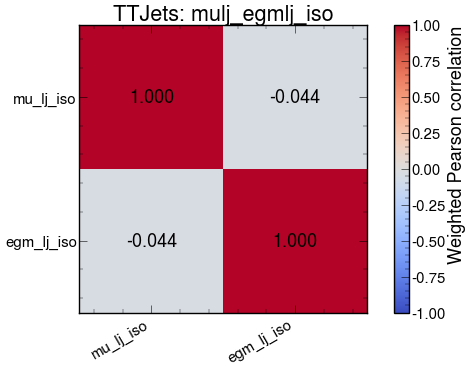

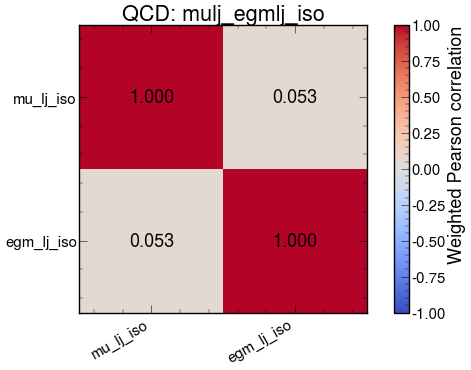

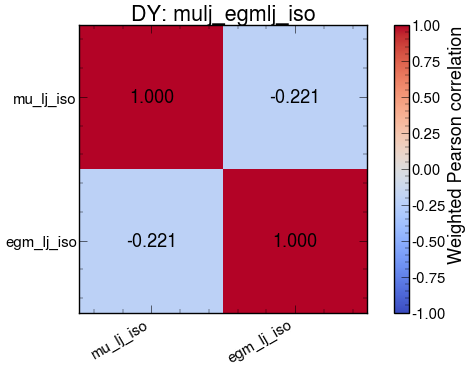

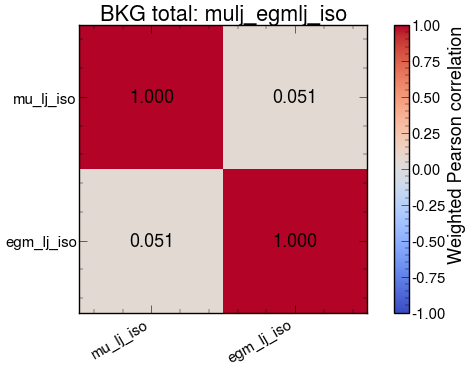


===== Correlation matrix: mulj_mulj_iso =====


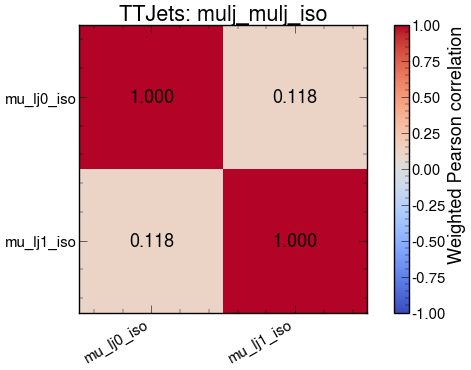

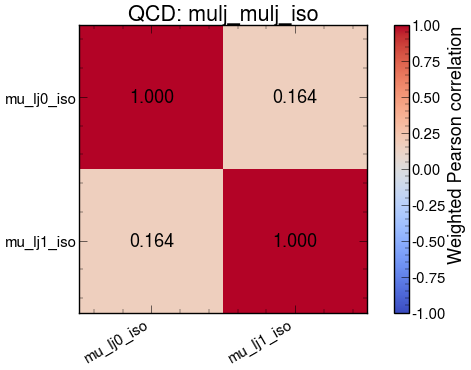

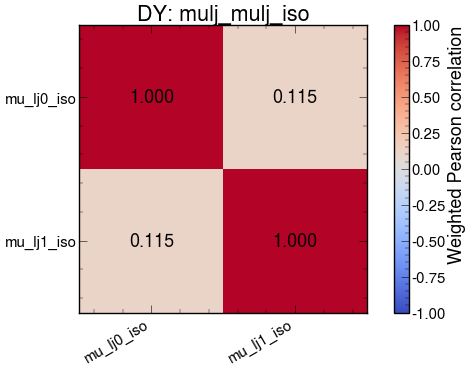

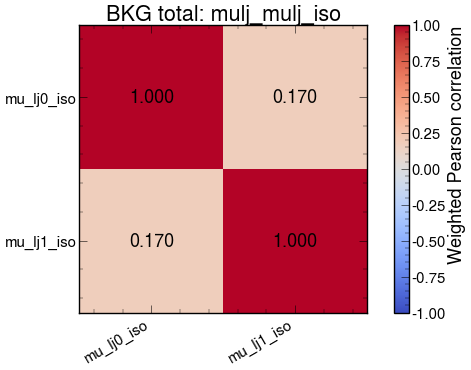

In [25]:
for hist_name in hist_configs:
    print()
    print(f"===== Correlation matrix: {hist_name} =====")
    for group in iter_available_groups():
        h2d = group_hist(group, hist_name)
        plot_correlation_matrix(h2d, group, hist_name)


## 다음 확장
- signal output이 준비되면 별도 group으로 추가해 sideband contamination과 sensitivity scan을 같은 방식으로 붙인다.
- data output은 A region blind 정책을 유지하면서 B/C/D sideband 중심으로 별도 section에서 다룬다.
